# 🔍 Pascal VOC 2012 — Exploratory Data Analysis

**Dataset:** Pascal Visual Object Classes (VOC) 2012  
**Source:** [Kaggle](https://www.kaggle.com/datasets/gopalbhattrai/pascal-voc-2012-dataset/data)

## Import Libraries

In [1]:
import os
import glob
import xml.etree.ElementTree as ET
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from scipy import stats
import cv2

# ── Aesthetics ──
sns.set_theme(style='whitegrid', palette='tab20')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('Libraries loaded ✅')

Libraries loaded ✅


## 1. Dataset Structure & Paths

Update `BASE_DIR` to wherever you unzipped the Kaggle download.  
Expected layout:
```
VOCdevkit/
└── VOC2012/
    ├── JPEGImages/          # .jpg images
    ├── Annotations/         # .xml bounding-box annotations
    ├── SegmentationClass/   # class segmentation PNGs
    ├── SegmentationObject/  # instance segmentation PNGs
    └── ImageSets/
        ├── Main/            # per-class train/val lists
        └── Segmentation/    # segmentation train/val lists
```

In [2]:
BASE_DIR = 'Dataset/VOC2012_train_val/VOC2012_train_val'

IMG_DIR   = os.path.join(BASE_DIR, 'JPEGImages')
ANN_DIR   = os.path.join(BASE_DIR, 'Annotations')
SEG_CLS   = os.path.join(BASE_DIR, 'SegmentationClass')
SEG_OBJ   = os.path.join(BASE_DIR, 'SegmentationObject')
SETS_DIR  = os.path.join(BASE_DIR, 'ImageSets', 'Main')

# Sanity-check
for d in [IMG_DIR, ANN_DIR, SEG_CLS, SETS_DIR]:
    status = '✅' if os.path.isdir(d) else '❌  NOT FOUND'
    print(f'{status}  {d}')

ann_files = sorted(glob.glob(os.path.join(ANN_DIR, '*.xml')))
img_files = sorted(glob.glob(os.path.join(IMG_DIR, '*.jpg')))
print(f'\nAnnotation XML files : {len(ann_files):,}')
print(f'JPEG image files     : {len(img_files):,}')

✅  Dataset/VOC2012_train_val/VOC2012_train_val/JPEGImages
✅  Dataset/VOC2012_train_val/VOC2012_train_val/Annotations
✅  Dataset/VOC2012_train_val/VOC2012_train_val/SegmentationClass
✅  Dataset/VOC2012_train_val/VOC2012_train_val/ImageSets/Main

Annotation XML files : 17,125
JPEG image files     : 17,125


## 2. Parse Annotations into a DataFrame

In [3]:
VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle',
    'bus','car','cat','chair','cow',
    'diningtable','dog','horse','motorbike','person',
    'pottedplant','sheep','sofa','train','tvmonitor'
]

def parse_annotation(xml_path):
    """Parse a VOC XML annotation and return a list of object dicts."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext('filename', default='')
    size_node = root.find('size')
    img_w = int(size_node.findtext('width',  default=0))
    img_h = int(size_node.findtext('height', default=0))
    img_d = int(size_node.findtext('depth',  default=0))
    segmented = int(root.findtext('segmented', default=0))

    rows = []
    for obj in root.findall('object'):
        name       = obj.findtext('name', default='').strip().lower()
        difficult  = int(obj.findtext('difficult', default=0))
        truncated  = int(obj.findtext('truncated', default=0))
        occluded   = int(obj.findtext('occluded',  default=0))
        pose       = obj.findtext('pose', default='Unspecified')

        bb = obj.find('bndbox')
        if bb is None:
            xmin = xmax = ymin = ymax = None
        else:
            xmin = float(bb.findtext('xmin', default=0))
            ymin = float(bb.findtext('ymin', default=0))
            xmax = float(bb.findtext('xmax', default=0))
            ymax = float(bb.findtext('ymax', default=0))

        rows.append(dict(
            filename=filename, img_w=img_w, img_h=img_h, img_d=img_d,
            segmented=segmented, label=name,
            difficult=difficult, truncated=truncated,
            occluded=occluded, pose=pose,
            xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax
        ))
    return rows

# Parse all annotations
records = []
for xml_path in tqdm(ann_files, desc='Parsing XML'):
    records.extend(parse_annotation(xml_path))

df = pd.DataFrame(records)

# Derived columns
df['bb_w']    = df['xmax'] - df['xmin']
df['bb_h']    = df['ymax'] - df['ymin']
df['bb_area'] = df['bb_w'] * df['bb_h']
df['img_area']= df['img_w'] * df['img_h']
df['bb_rel_area'] = df['bb_area'] / df['img_area']   # fractional coverage
df['aspect_ratio']= df['img_w'] / df['img_h'].replace(0, np.nan)
df['bb_aspect']   = df['bb_w']  / df['bb_h'].replace(0, np.nan)

print(f'Total object instances : {len(df):,}')
print(f'Unique images          : {df["filename"].nunique():,}')
print(f'Unique classes found   : {df["label"].nunique()}')
print()
df.head()

Parsing XML: 100%|██████████████████████████████████████████████████████████████████████████████████| 17125/17125 [00:03<00:00, 5004.25it/s]


Total object instances : 40,138
Unique images          : 17,125
Unique classes found   : 20



,filename,img_w,img_h,img_d,segmented,label,difficult,truncated,occluded,pose,...,ymin,xmax,ymax,bb_w,bb_h,bb_area,img_area,bb_rel_area,aspect_ratio,bb_aspect
0,2007_000027.jpg,486,500,3,0,person,0,0,0,Unspecified,...,101.0,349.0,351.0,175.0,250.0,43750.0,243000,0.180041,0.972000,0.700000
1,2007_000032.jpg,500,281,3,1,aeroplane,0,0,0,Frontal,...,78.0,375.0,183.0,271.0,105.0,28455.0,140500,0.202527,1.779359,2.580952
2,2007_000032.jpg,500,281,3,1,aeroplane,0,0,0,Left,...,88.0,197.0,123.0,64.0,35.0,2240.0,140500,0.015943,1.779359,1.828571
3,2007_000032.jpg,500,281,3,1,person,0,0,0,Rear,...,180.0,213.0,229.0,18.0,49.0,882.0,140500,0.006278,1.779359,0.367347
4,2007_000032.jpg,500,281,3,1,person,0,0,0,Rear,...,189.0,44.0,238.0,18.0,49.0,882.0,140500,0.006278,1.779359,0.367347


## 3. Missing Values & Data Integrity

In [4]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
mv_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(mv_df[mv_df['Missing Count'] > 0].to_string() or 'None ✅')

print('\n=== Zero/Invalid Bounding Box Dimensions ===')
bad_w  = (df['bb_w']  <= 0).sum()
bad_h  = (df['bb_h']  <= 0).sum()
bad_sz = ((df['img_w'] == 0) | (df['img_h'] == 0)).sum()
print(f'  BB width  ≤ 0  : {bad_w}')
print(f'  BB height ≤ 0  : {bad_h}')
print(f'  Image size = 0 : {bad_sz}')

print('\n=== Out-of-bounds Bounding Boxes ===')
oob = df[(df['xmin'] < 0) | (df['ymin'] < 0) |
          (df['xmax'] > df['img_w']) | (df['ymax'] > df['img_h'])]
print(f'  Out-of-bounds objects : {len(oob)}')

print('\n=== Unknown Labels (not in VOC 20-class list) ===')
unknown = df[~df['label'].isin(VOC_CLASSES)]['label'].value_counts()
print(unknown if len(unknown) else 'None ✅')

print('\n=== Images without corresponding annotation ===')
ann_stems = {os.path.splitext(os.path.basename(p))[0] for p in ann_files}
img_stems = {os.path.splitext(os.path.basename(p))[0] for p in img_files}
imgs_no_ann = img_stems - ann_stems
anns_no_img = ann_stems - img_stems
print(f'  Images with no annotation : {len(imgs_no_ann)}')
print(f'  Annotations with no image : {len(anns_no_img)}')

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

=== Zero/Invalid Bounding Box Dimensions ===
  BB width  ≤ 0  : 0
  BB height ≤ 0  : 0
  Image size = 0 : 0

=== Out-of-bounds Bounding Boxes ===
  Out-of-bounds objects : 0

=== Unknown Labels (not in VOC 20-class list) ===
None ✅

=== Images without corresponding annotation ===
  Images with no annotation : 0
  Annotations with no image : 0


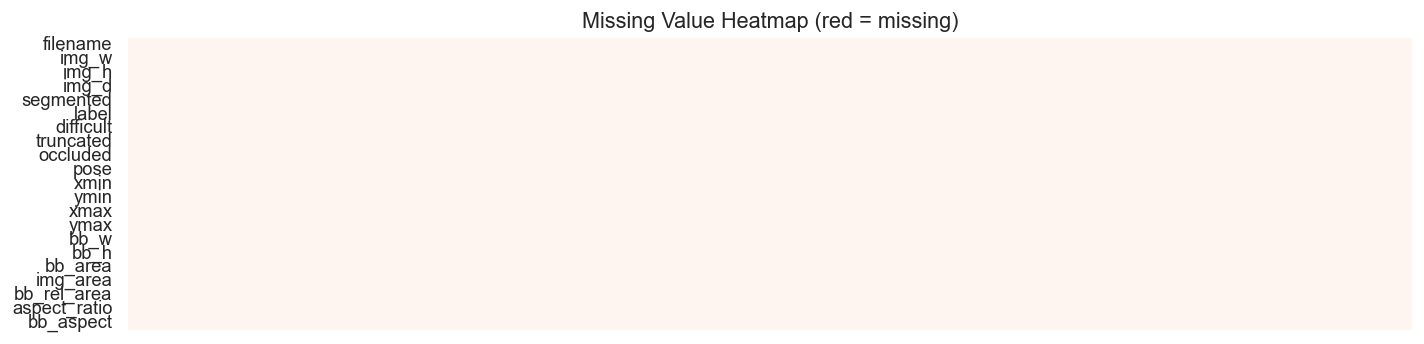

In [5]:
# Visualise missing values as a heatmap
fig, ax = plt.subplots(figsize=(12, 3))
miss_matrix = df.isnull().astype(int)
sns.heatmap(miss_matrix.T, ax=ax, cbar=False, cmap='Reds',
            xticklabels=False, yticklabels=True)
ax.set_title('Missing Value Heatmap (red = missing)', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Class Distribution & Imbalance Analysis

In [6]:
class_counts = df['label'].value_counts()
print('Object instances per class:')
print(class_counts.to_string())

# Imbalance ratio
imbalance_ratio = class_counts.max() / class_counts.min()
print(f'\nImbalance ratio (max/min): {imbalance_ratio:.1f}x')

Object instances per class:
label
person         17401
chair           3056
car             2492
dog             1598
bottle          1561
cat             1277
bird            1271
pottedplant     1202
sheep           1084
boat            1059
aeroplane       1002
tvmonitor        893
sofa             841
bicycle          837
horse            803
motorbike        801
diningtable      800
cow              771
train            704
bus              685

Imbalance ratio (max/min): 25.4x


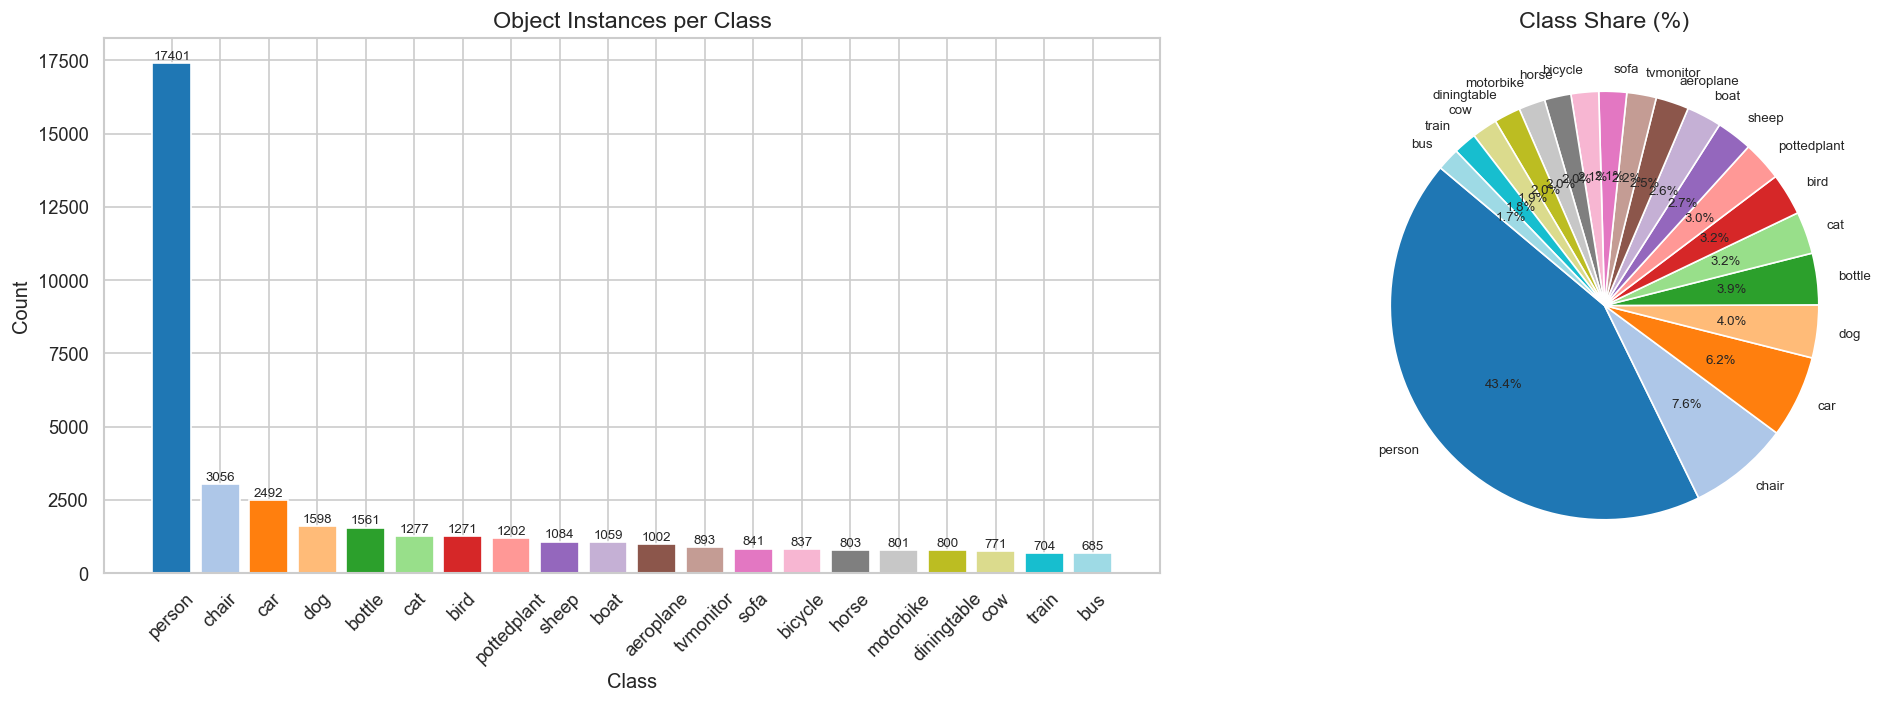

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart
ax = axes[0]
colors = sns.color_palette('tab20', len(class_counts))
bars = ax.bar(class_counts.index, class_counts.values, color=colors)
ax.set_title('Object Instances per Class', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            str(v), ha='center', va='bottom', fontsize=8)

# Pie chart for top-level share
ax2 = axes[1]
ax2.pie(class_counts.values, labels=class_counts.index,
        autopct='%1.1f%%', colors=colors, startangle=140,
        textprops={'fontsize': 8})
ax2.set_title('Class Share (%)', fontsize=14)

plt.tight_layout()
plt.show()

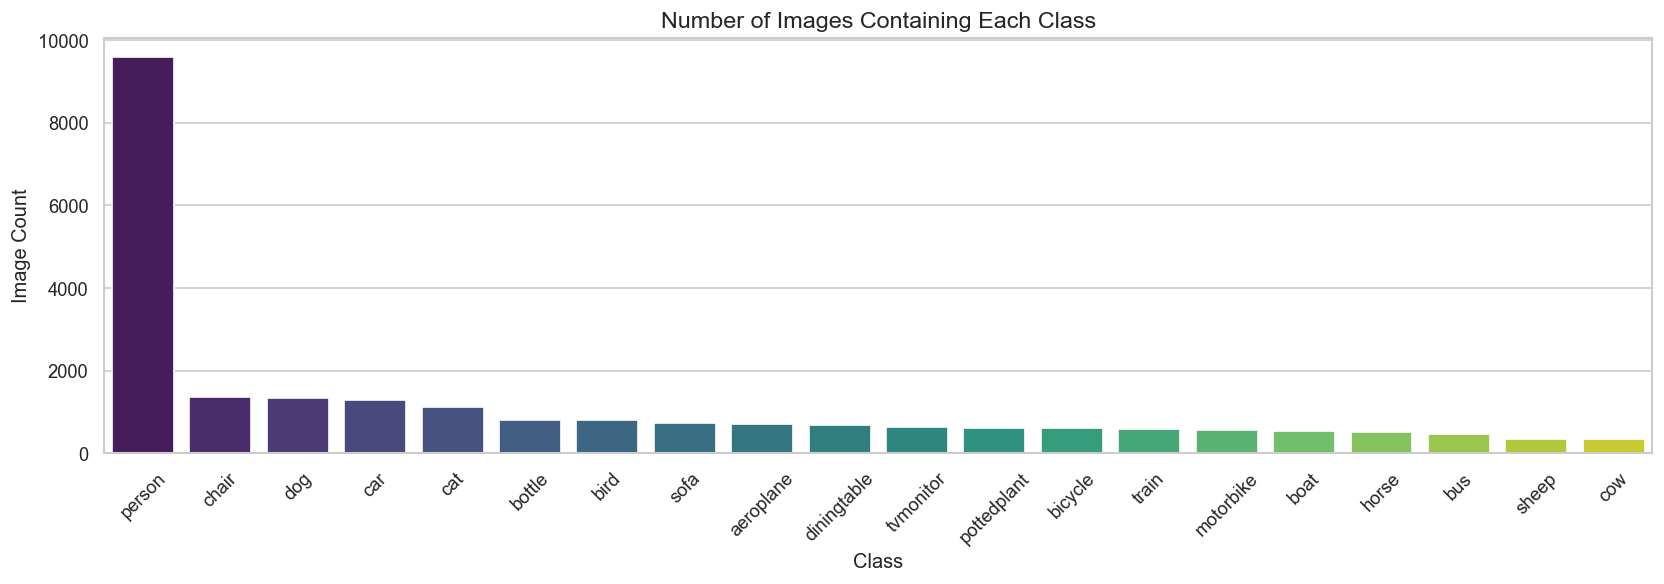

In [8]:
# Images per class (images that CONTAIN at least one object of that class)
imgs_per_class = df.groupby('label')['filename'].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
sns.barplot(x=imgs_per_class.index, y=imgs_per_class.values,
            palette='viridis', ax=ax)
ax.set_title('Number of Images Containing Each Class', fontsize=14)
ax.set_xlabel('Class')
ax.set_ylabel('Image Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 5. Objects-per-Image Distribution

Objects-per-image statistics:
count    17125.00
mean         2.34
std          2.42
min          1.00
25%          1.00
50%          1.00
75%          3.00
max         56.00
dtype: float64

Images with 1 object  : 8966
Images with >5 objects: 1391
Max objects in one image: 56


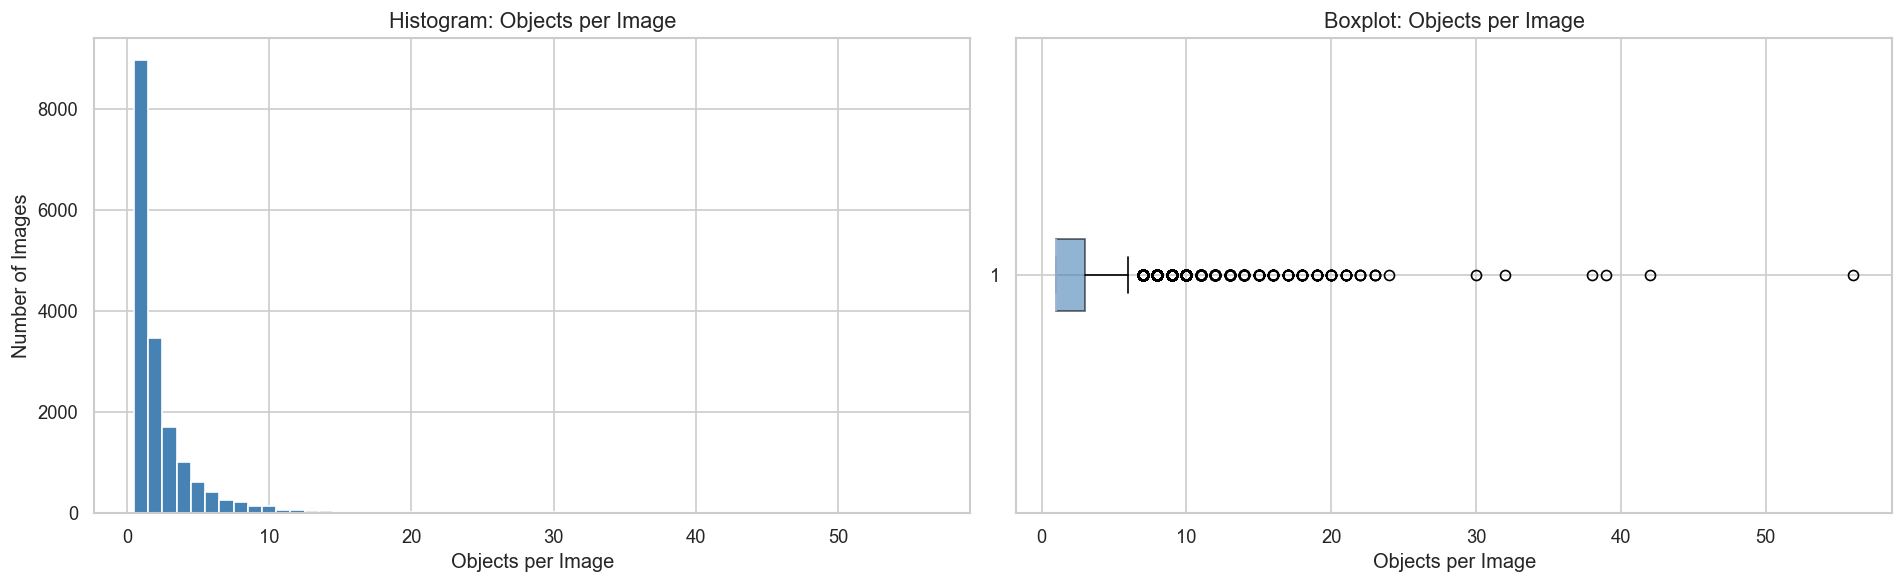

In [9]:
obj_per_img = df.groupby('filename').size()

print('Objects-per-image statistics:')
print(obj_per_img.describe().round(2))
print(f'\nImages with 1 object  : {(obj_per_img == 1).sum()}')
print(f'Images with >5 objects: {(obj_per_img > 5).sum()}')
print(f'Max objects in one image: {obj_per_img.max()}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(obj_per_img, bins=range(1, obj_per_img.max()+2),
             color='steelblue', edgecolor='white', align='left')
axes[0].set_title('Histogram: Objects per Image', fontsize=13)
axes[0].set_xlabel('Objects per Image')
axes[0].set_ylabel('Number of Images')

axes[1].boxplot(obj_per_img, vert=False, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Boxplot: Objects per Image', fontsize=13)
axes[1].set_xlabel('Objects per Image')

plt.tight_layout()
plt.show()

## 6. Image Size & Aspect Ratio Analysis

In [10]:
img_meta = df.drop_duplicates('filename')[['filename','img_w','img_h','img_d','aspect_ratio']].copy()

print('Image width  statistics:')
print(img_meta['img_w'].describe().round(1))
print('\nImage height statistics:')
print(img_meta['img_h'].describe().round(1))

unique_sizes = img_meta.groupby(['img_w','img_h']).size().reset_index(name='count')
print(f'\nUnique (width, height) combinations: {len(unique_sizes)}')
print('Top 10 most common resolutions:')
print(unique_sizes.sort_values('count', ascending=False).head(10).to_string(index=False))

Image width  statistics:
count    17125.0
mean       466.8
std         61.9
min        142.0
25%        499.0
50%        500.0
75%        500.0
max        500.0
Name: img_w, dtype: float64

Image height statistics:
count    17125.0
mean       389.5
std         65.5
min         71.0
25%        338.0
50%        375.0
75%        400.0
max        500.0
Name: img_h, dtype: float64

Unique (width, height) combinations: 977
Top 10 most common resolutions:
 img_w  img_h  count
   500    375   7061
   500    333   2095
   375    500   1652
   333    500    636
   500    334    356
   500    332    333
   500    374    155
   500    335    138
   334    500    104
   500    400     99


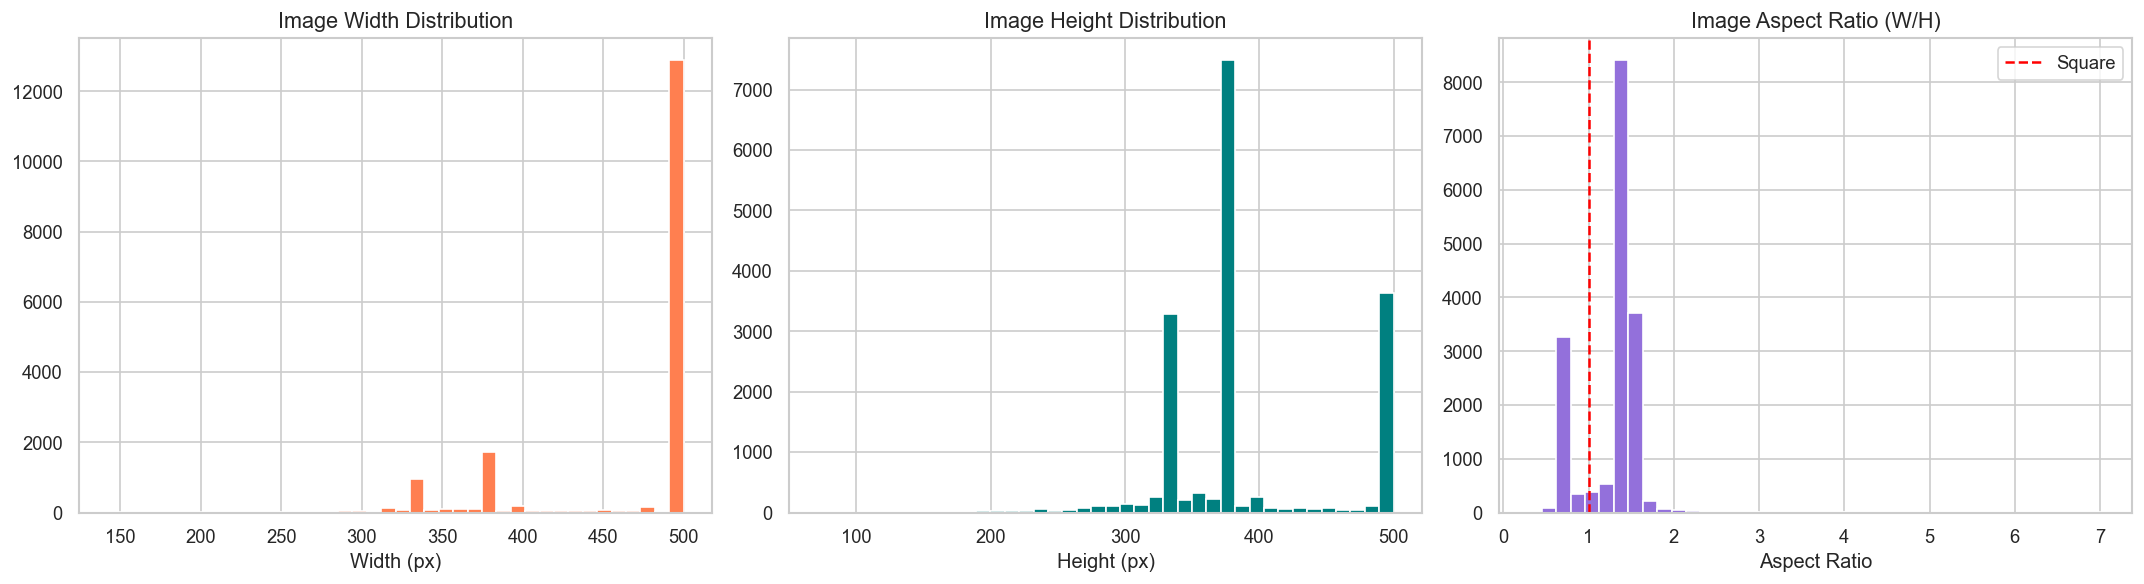

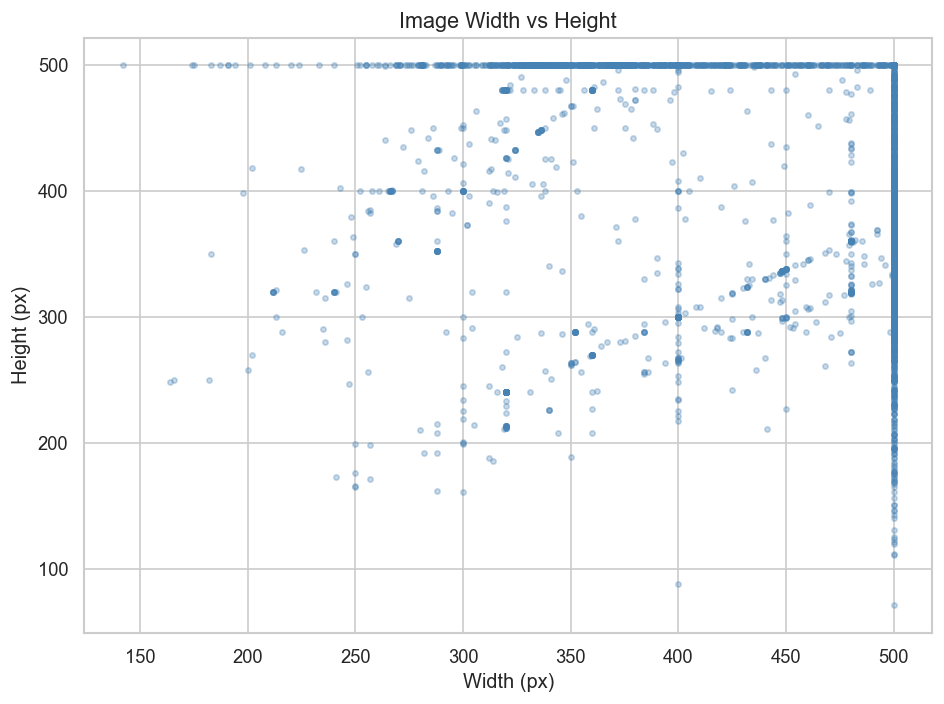

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width distribution
axes[0].hist(img_meta['img_w'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Image Width Distribution', fontsize=13)
axes[0].set_xlabel('Width (px)')

# Height distribution
axes[1].hist(img_meta['img_h'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('Image Height Distribution', fontsize=13)
axes[1].set_xlabel('Height (px)')

# Aspect ratio
axes[2].hist(img_meta['aspect_ratio'].dropna(), bins=40, color='mediumpurple', edgecolor='white')
axes[2].axvline(1.0, color='red', linestyle='--', label='Square')
axes[2].set_title('Image Aspect Ratio (W/H)', fontsize=13)
axes[2].set_xlabel('Aspect Ratio')
axes[2].legend()

plt.tight_layout()
plt.show()

# 2D scatter of width vs height
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(img_meta['img_w'], img_meta['img_h'], alpha=0.3, s=10, c='steelblue')
ax.set_title('Image Width vs Height', fontsize=13)
ax.set_xlabel('Width (px)')
ax.set_ylabel('Height (px)')
plt.tight_layout()
plt.show()

## 7. Bounding Box Analysis & Outlier Detection

In [12]:
bb_df = df.dropna(subset=['bb_w','bb_h','bb_area']).copy()

print('Bounding Box Width:')
print(bb_df['bb_w'].describe().round(1))
print('\nBounding Box Height:')
print(bb_df['bb_h'].describe().round(1))
print('\nBB Area (px²):')
print(bb_df['bb_area'].describe().round(1))
print('\nRelative BB Area (fraction of image):')
print(bb_df['bb_rel_area'].describe().round(4))

Bounding Box Width:
count    40138.0
mean       158.5
std        130.9
min          2.0
25%         54.0
50%        116.0
75%        233.0
max        499.0
Name: bb_w, dtype: float64

Bounding Box Height:
count    40138.0
mean       173.3
std        116.9
min          4.0
25%         73.0
50%        153.0
75%        257.0
max        499.0
Name: bb_h, dtype: float64

BB Area (px²):
count     40138.0
mean      37342.5
std       44537.8
min          14.0
25%        4140.0
50%       18290.0
75%       55375.8
max      249001.0
Name: bb_area, dtype: float64

Relative BB Area (fraction of image):
count    40138.0000
mean         0.2081
std          0.2449
min          0.0001
25%          0.0232
50%          0.1030
75%          0.3110
max          0.9960
Name: bb_rel_area, dtype: float64


In [13]:
# IQR-based outlier detection on BB area
Q1, Q3 = bb_df['bb_area'].quantile(0.25), bb_df['bb_area'].quantile(0.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = bb_df[(bb_df['bb_area'] < lower) | (bb_df['bb_area'] > upper)]
print(f'BB Area outliers (IQR method): {len(outliers):,}  '
      f'({100*len(outliers)/len(bb_df):.1f}%)')
print(f'  Lower fence: {lower:.0f} px²')
print(f'  Upper fence: {upper:.0f} px²')
print()
print('Outlier breakdown by class:')
print(outliers['label'].value_counts().to_string())

BB Area outliers (IQR method): 2,328  (5.8%)
  Lower fence: -72714 px²
  Upper fence: 132229 px²

Outlier breakdown by class:
label
person         727
cat            283
dog            211
sofa           159
car            111
motorbike      101
bicycle         91
chair           84
train           74
aeroplane       71
horse           62
diningtable     57
bird            53
bus             50
pottedplant     46
cow             43
boat            37
sheep           36
tvmonitor       23
bottle           9


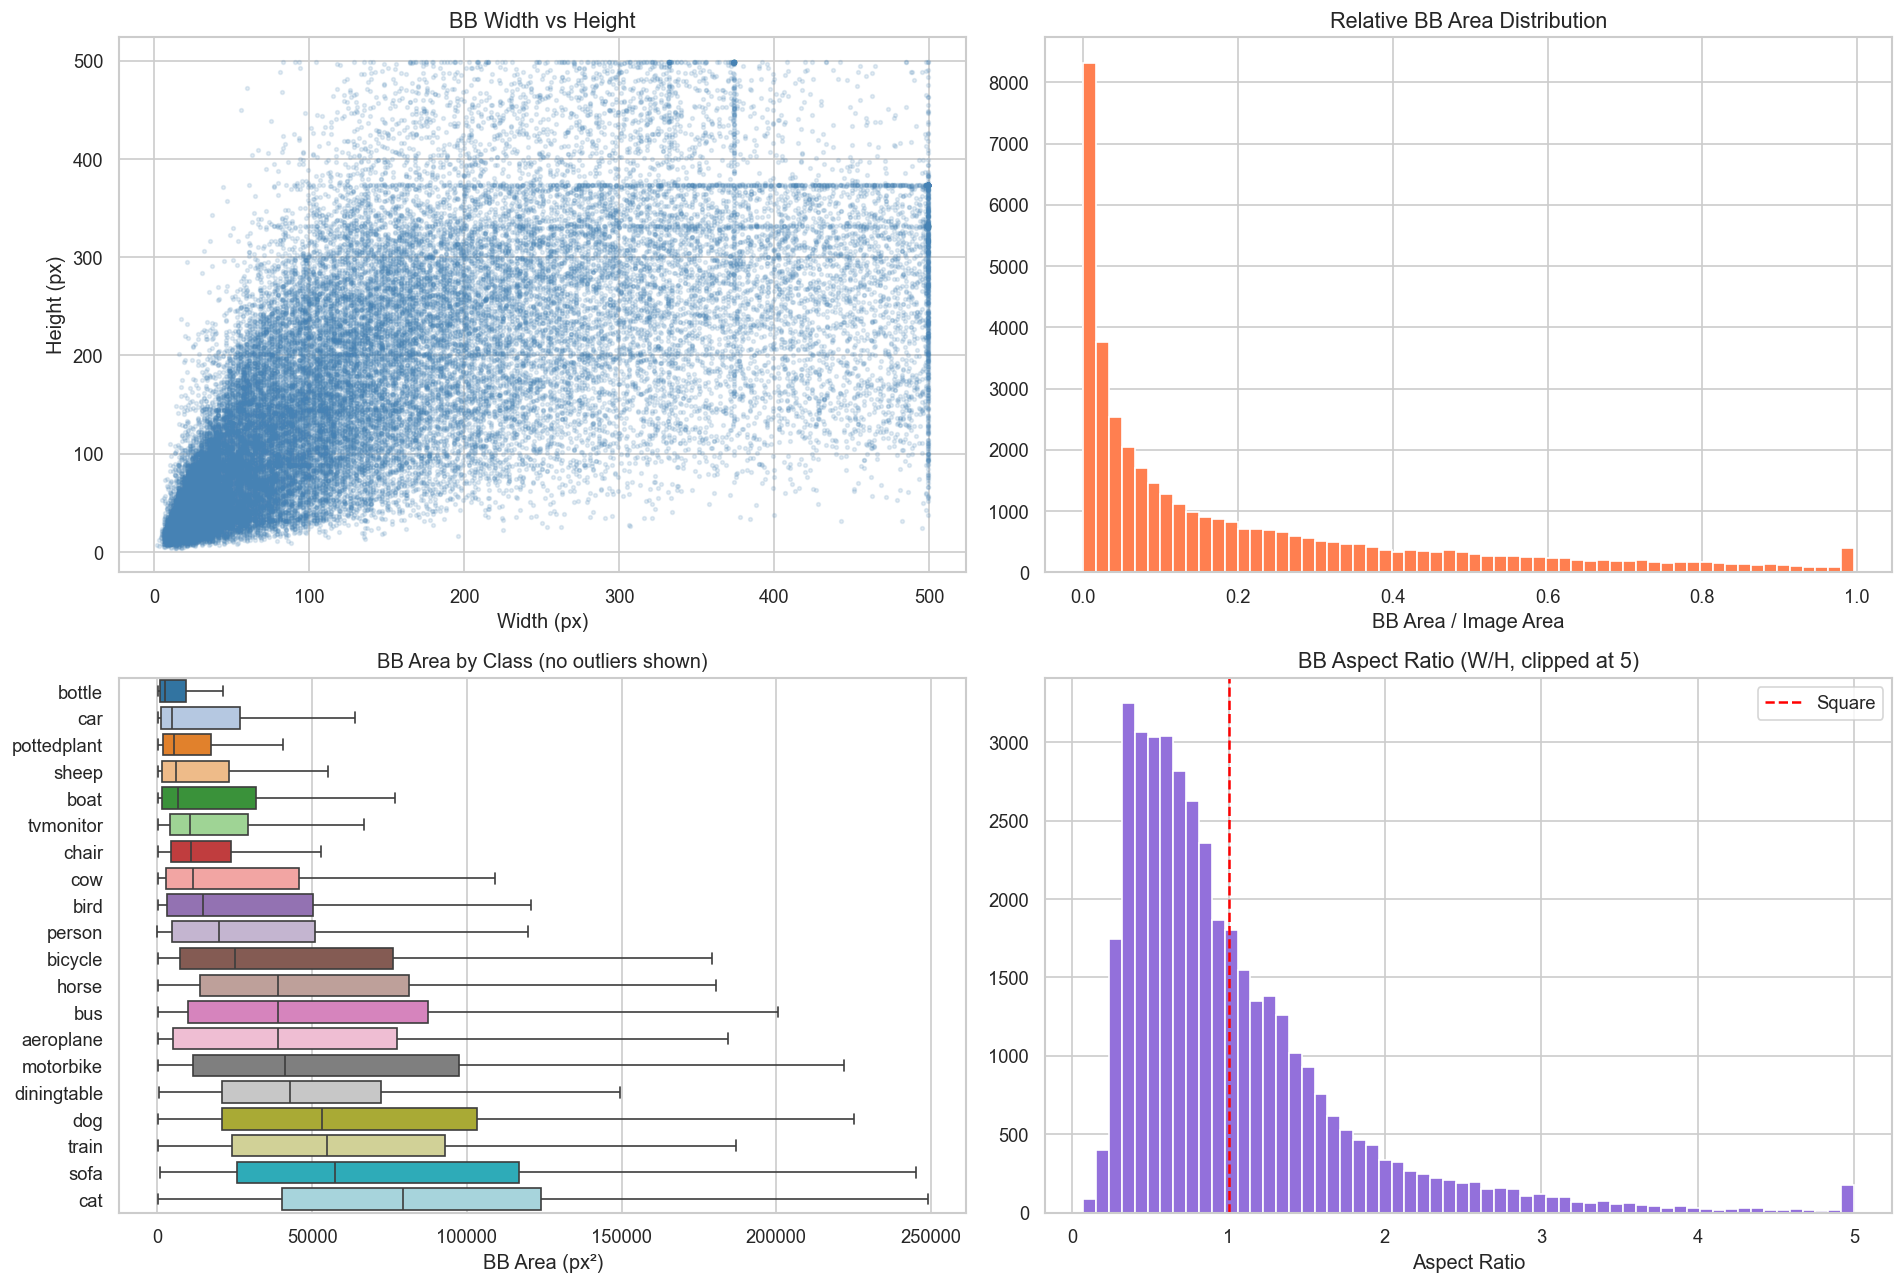

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# BB width vs height scatter
axes[0,0].scatter(bb_df['bb_w'], bb_df['bb_h'], alpha=0.15, s=5, c='steelblue')
axes[0,0].set_title('BB Width vs Height', fontsize=13)
axes[0,0].set_xlabel('Width (px)')
axes[0,0].set_ylabel('Height (px)')

# Relative BB area distribution
axes[0,1].hist(bb_df['bb_rel_area'], bins=60, color='coral', edgecolor='white')
axes[0,1].set_title('Relative BB Area Distribution', fontsize=13)
axes[0,1].set_xlabel('BB Area / Image Area')

# Box plot of BB area per class
# Box plot of BB area per class (seaborn — supports 'order')
class_order = bb_df.groupby('label')['bb_area'].median().sort_values().index.tolist()
sns.boxplot(
    data=bb_df, y='label', x='bb_area', ax=axes[1,0],
    order=class_order, orient='h', showfliers=False,
    palette='tab20'
)
axes[1,0].set_title('BB Area by Class (no outliers shown)', fontsize=12)
axes[1,0].set_xlabel('BB Area (px²)')
axes[1,0].set_ylabel('')

# BB aspect ratio distribution
axes[1,1].hist(bb_df['bb_aspect'].clip(0, 5), bins=60,
               color='mediumpurple', edgecolor='white')
axes[1,1].axvline(1.0, color='red', linestyle='--', label='Square')
axes[1,1].set_title('BB Aspect Ratio (W/H, clipped at 5)', fontsize=13)
axes[1,1].set_xlabel('Aspect Ratio')
axes[1,1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()

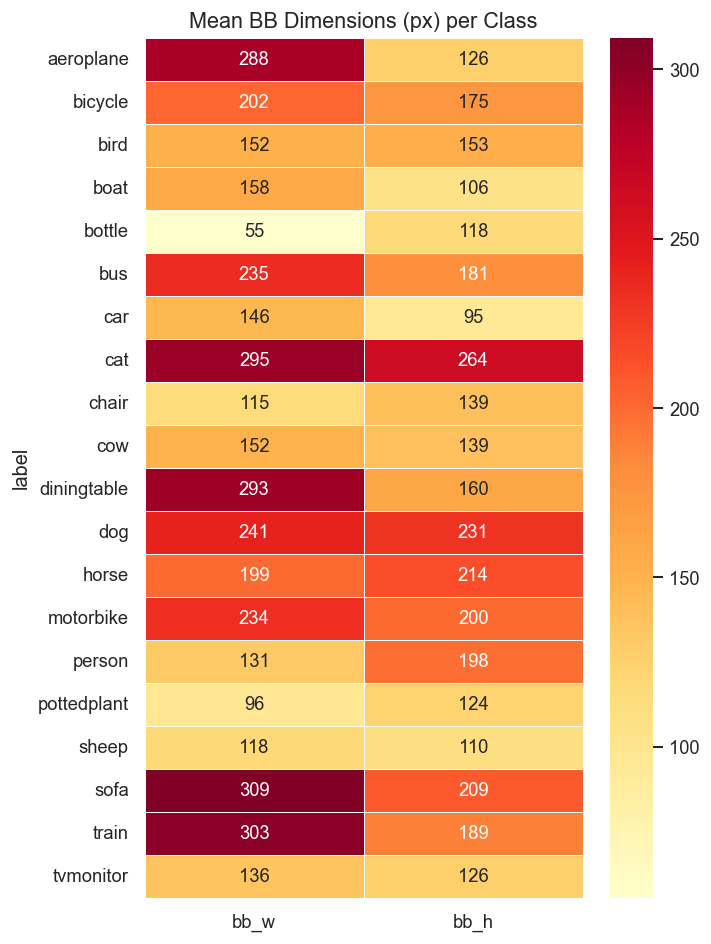

In [15]:
# Mean BB size heatmap per class (width vs height)
bb_size = bb_df.groupby('label')[['bb_w','bb_h']].mean().round(1)

fig, ax = plt.subplots(figsize=(6, 8))
sns.heatmap(bb_size, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax)
ax.set_title('Mean BB Dimensions (px) per Class', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Difficult / Truncated / Occluded Object Analysis

           Count      %
difficult   4462  11.12
truncated  17599  43.85
occluded   13299  33.13


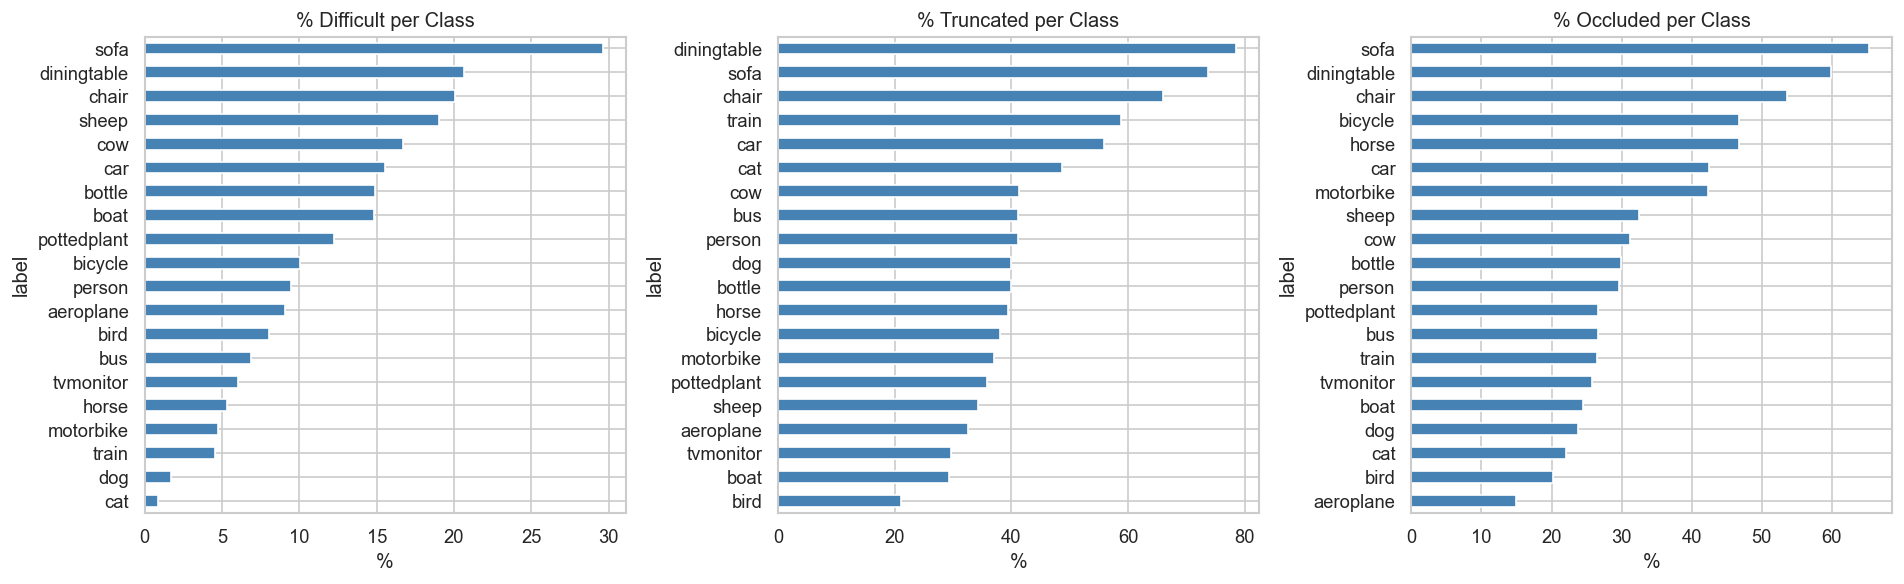

In [16]:
flags = ['difficult', 'truncated', 'occluded']
flag_counts = df[flags].sum().rename('Count')
flag_pct    = (df[flags].mean() * 100).rename('%').round(2)
print(pd.concat([flag_counts, flag_pct], axis=1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, flags):
    per_class = df.groupby('label')[col].mean().sort_values() * 100
    per_class.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'% {col.capitalize()} per Class', fontsize=12)
    ax.set_xlabel('%')
plt.tight_layout()
plt.show()

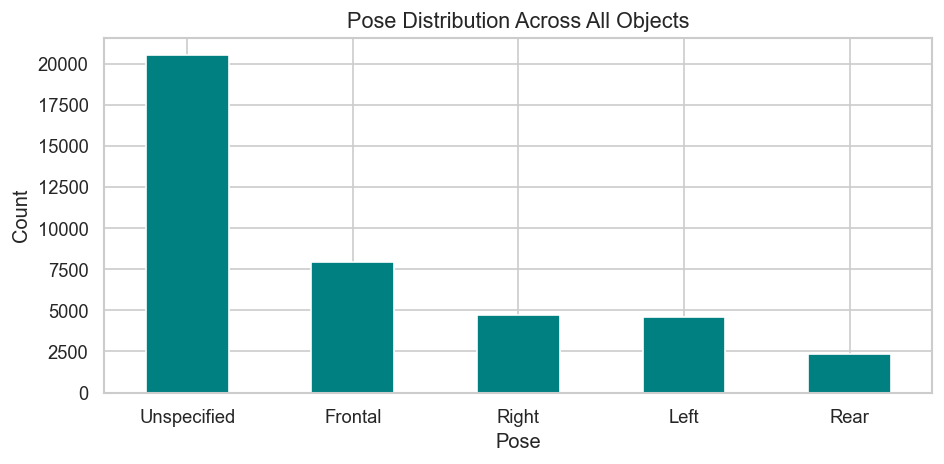

In [17]:
# Pose distribution
pose_counts = df['pose'].value_counts()
fig, ax = plt.subplots(figsize=(8, 4))
pose_counts.plot(kind='bar', ax=ax, color='teal', edgecolor='white')
ax.set_title('Pose Distribution Across All Objects', fontsize=13)
ax.set_xlabel('Pose')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 9. Train / Validation Split Analysis

In [18]:
def read_split_file(path):
    """Read a VOC image-set .txt file and return image IDs."""
    with open(path) as f:
        lines = [l.strip().split()[0] for l in f if l.strip()]
    return set(lines)

train_ids = read_split_file(os.path.join(SETS_DIR, 'train.txt'))
val_ids   = read_split_file(os.path.join(SETS_DIR, 'val.txt'))
trainval  = read_split_file(os.path.join(SETS_DIR, 'trainval.txt'))

print(f'Train images    : {len(train_ids):,}')
print(f'Val   images    : {len(val_ids):,}')
print(f'TrainVal total  : {len(trainval):,}')
print(f'Overlap train∩val: {len(train_ids & val_ids)}')

# Map split to df
def get_split(fn):
    stem = os.path.splitext(fn)[0]
    if stem in train_ids: return 'train'
    if stem in val_ids:   return 'val'
    return 'unknown'

df['split'] = df['filename'].apply(get_split)

split_class = df.groupby(['split','label']).size().unstack(fill_value=0)
print('\nClass counts by split:')
print(split_class.to_string())

Train images    : 5,717
Val   images    : 5,823
TrainVal total  : 11,540
Overlap train∩val: 0

Class counts by split:
label    aeroplane  bicycle  bird  boat  bottle  bus   car  cat  chair  cow  diningtable  dog  horse  motorbike  person  pottedplant  sheep  sofa  train  tvmonitor
split                                                                                                                                                              
train          470      410   592   508     749  317  1191  609   1457  355          373  768    377        375    5019          557    509   399    327        412
unknown         48       47    50    60      79   48   128   50    150   69           53   57     53         50    7272          103     90    55     48         67
val            484      380   629   491     733  320  1173  618   1449  347          374  773    373        376    5110          542    485   387    329        414


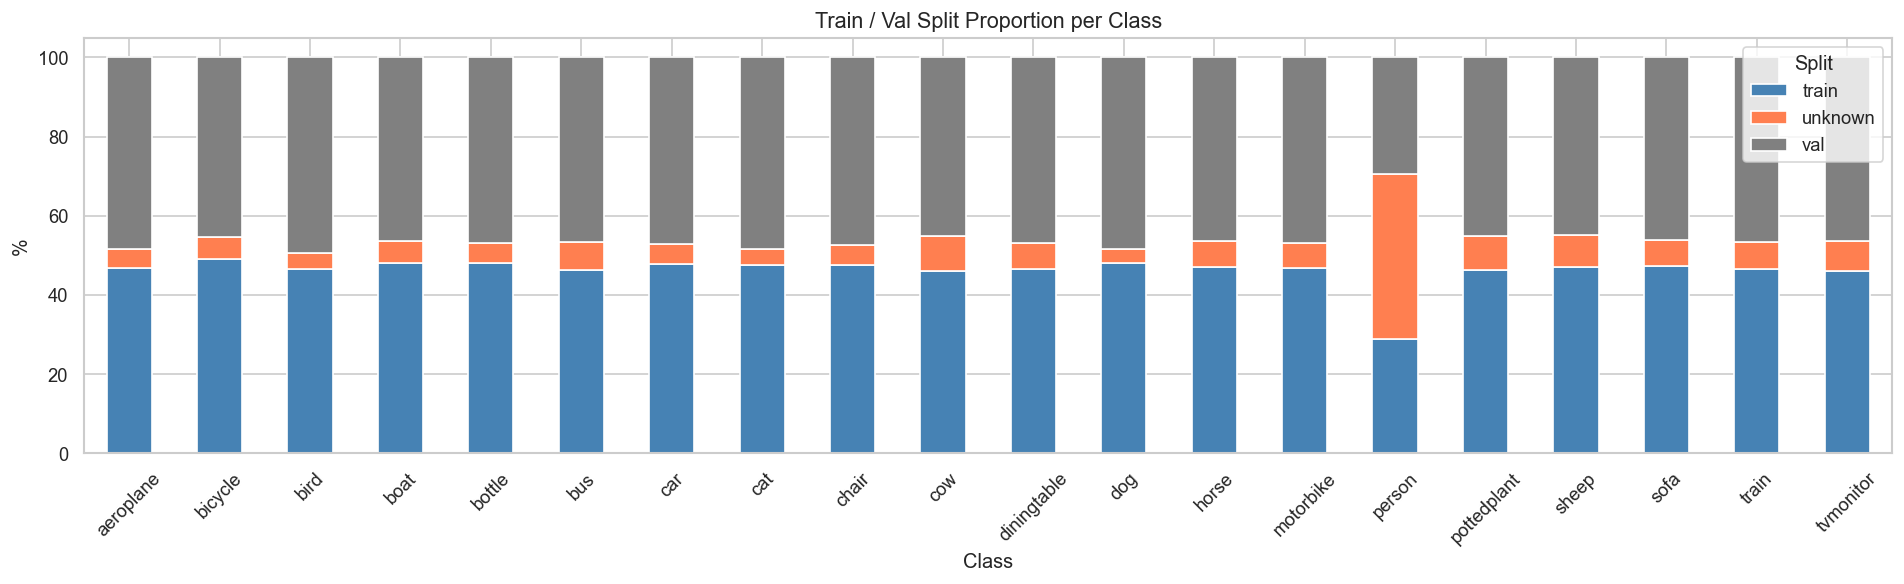

In [19]:
# Split proportions per class
split_class_norm = split_class.div(split_class.sum(axis=0), axis=1) * 100

fig, ax = plt.subplots(figsize=(16, 5))
split_class_norm.T.plot(kind='bar', stacked=True, ax=ax,
                         color=['steelblue','coral','grey'])
ax.set_title('Train / Val Split Proportion per Class', fontsize=13)
ax.set_ylabel('%')
ax.set_xlabel('Class')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Split')
plt.tight_layout()
plt.show()

## 10. Segmentation Mask Analysis

Segmentation class masks : 2,913


Reading masks: 100%|████████████████████████████████████████████████████████████████████████████████████| 500/500 [00:00<00:00, 1110.93it/s]


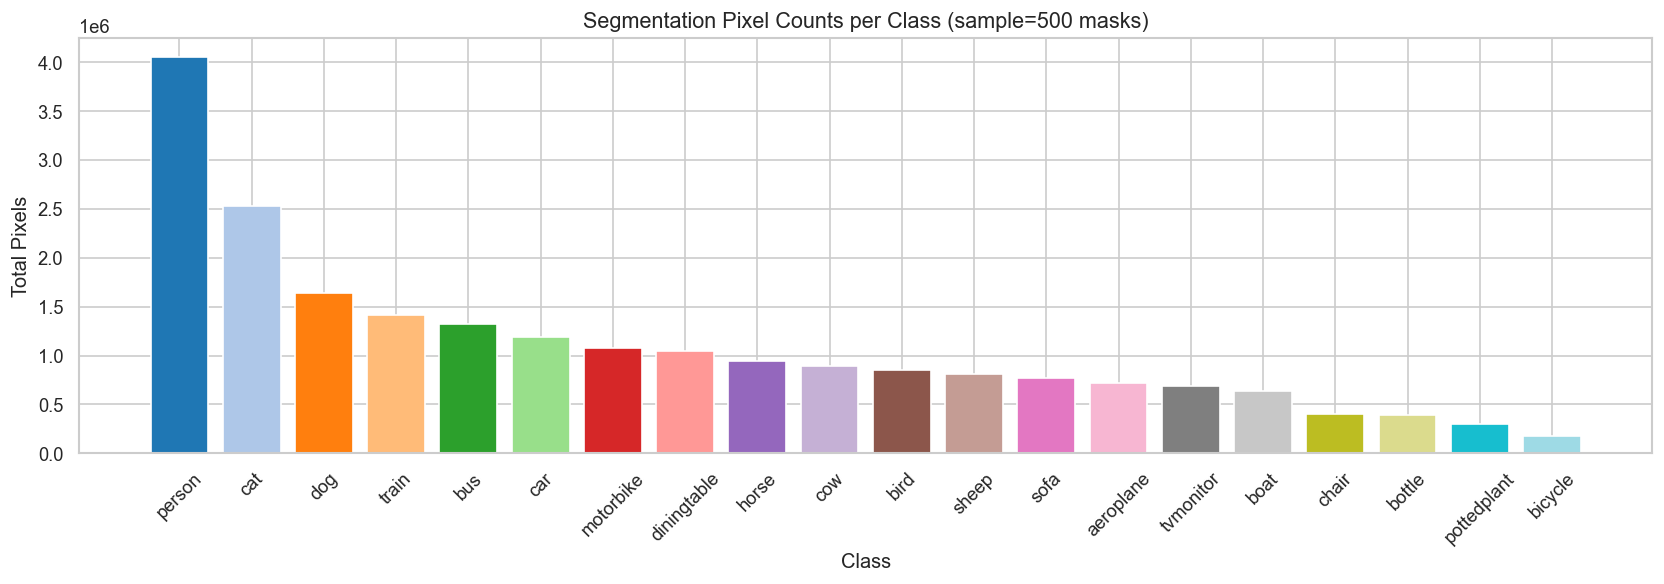

In [20]:
seg_files = glob.glob(os.path.join(SEG_CLS, '*.png'))
print(f'Segmentation class masks : {len(seg_files):,}')

# VOC palette: index → class name (0=bg, 255=void)
VOC_COLORMAP_IDX = {i+1: c for i, c in enumerate(VOC_CLASSES)}
VOC_COLORMAP_IDX[0]   = 'background'
VOC_COLORMAP_IDX[255] = 'void/boundary'

pixel_counts = {k: 0 for k in VOC_COLORMAP_IDX}
sample_limit = min(500, len(seg_files))   # analyse up to 500 masks for speed

for p in tqdm(seg_files[:sample_limit], desc='Reading masks'):
    mask = np.array(Image.open(p))
    for idx in np.unique(mask):
        if idx in pixel_counts:
            pixel_counts[idx] += np.sum(mask == idx)

# Filter out background & void for the plot
seg_counts = {
    VOC_COLORMAP_IDX[k]: v
    for k, v in sorted(pixel_counts.items(), key=lambda x: -x[1])
    if k not in [0, 255] and v > 0
}

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(seg_counts.keys(), seg_counts.values(),
       color=sns.color_palette('tab20', len(seg_counts)))
ax.set_title(f'Segmentation Pixel Counts per Class (sample={sample_limit} masks)',
             fontsize=13)
ax.set_xlabel('Class')
ax.set_ylabel('Total Pixels')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 11. Sample Image Visualizations with Bounding Boxes

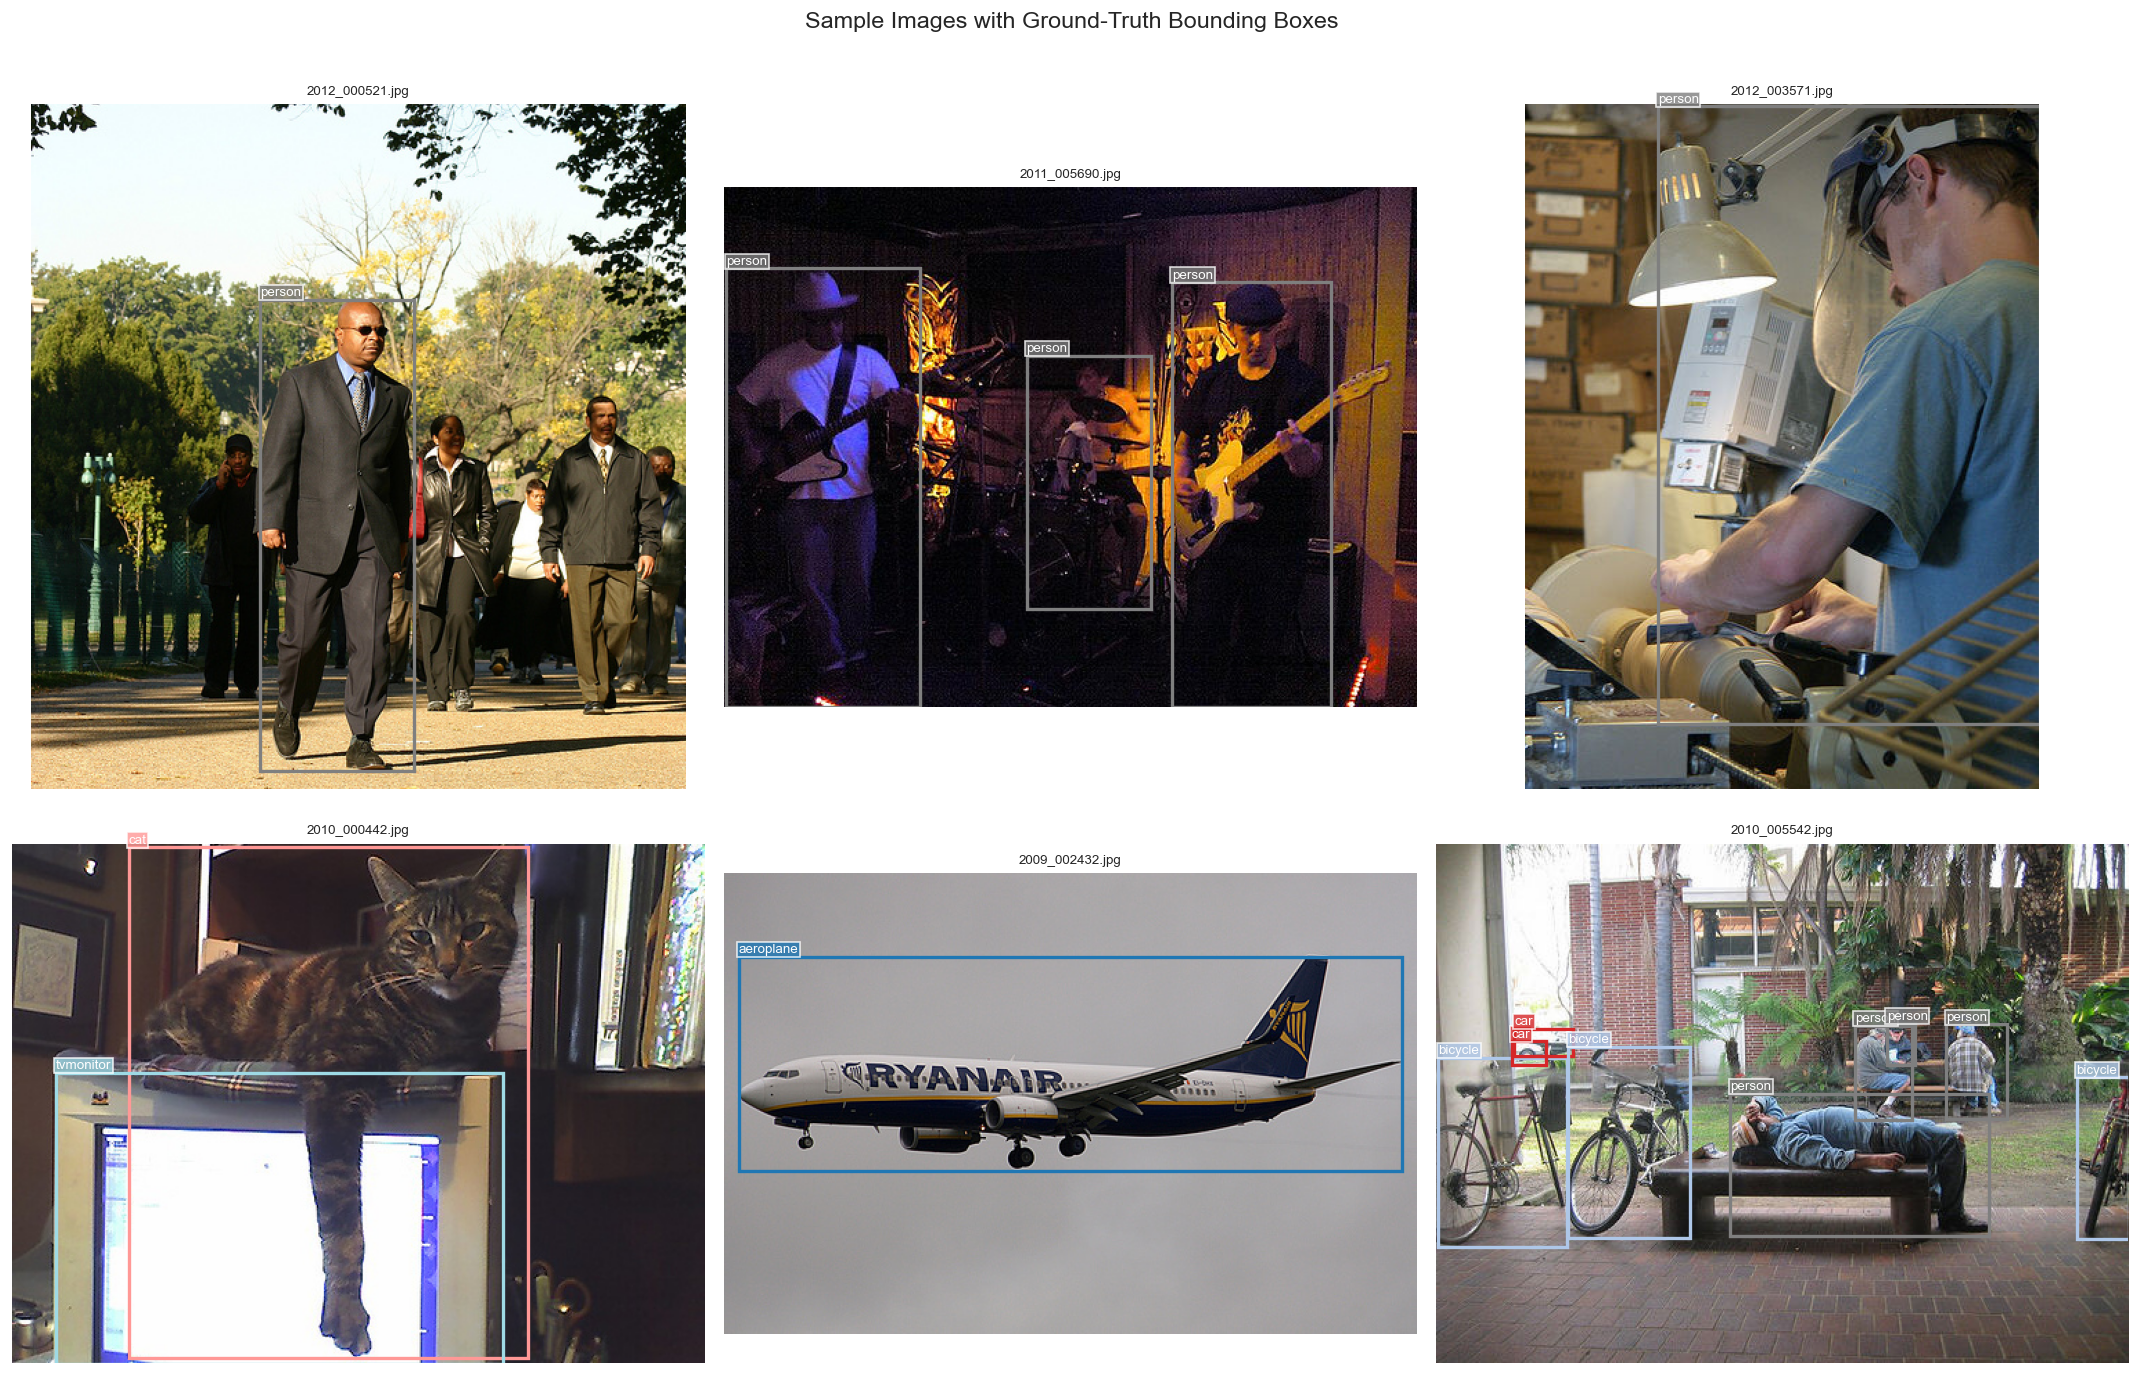

In [21]:
def show_annotated_images(df, img_dir, n=6, seed=42):
    np.random.seed(seed)
    sample_imgs = np.random.choice(df['filename'].unique(), n, replace=False)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(18, 6*rows))
    axes = axes.flatten()

    colors_map = {c: plt.cm.tab20(i/20) for i, c in enumerate(VOC_CLASSES)}

    for ax, fname in zip(axes, sample_imgs):
        img_path = os.path.join(img_dir, fname)
        if not os.path.exists(img_path):
            ax.axis('off')
            continue
        img = np.array(Image.open(img_path))
        ax.imshow(img)
        objs = df[df['filename'] == fname]
        for _, row in objs.iterrows():
            if pd.isna(row['xmin']):
                continue
            color = colors_map.get(row['label'], (1,0,0,1))
            rect = patches.Rectangle(
                (row['xmin'], row['ymin']), row['bb_w'], row['bb_h'],
                linewidth=2, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(row['xmin'], row['ymin'] - 3,
                    row['label'], color='white', fontsize=8,
                    bbox=dict(facecolor=color, alpha=0.8, pad=1))
        ax.set_title(fname, fontsize=8)
        ax.axis('off')

    for ax in axes[n:]:
        ax.axis('off')

    plt.suptitle('Sample Images with Ground-Truth Bounding Boxes', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

show_annotated_images(df, IMG_DIR, n=6)

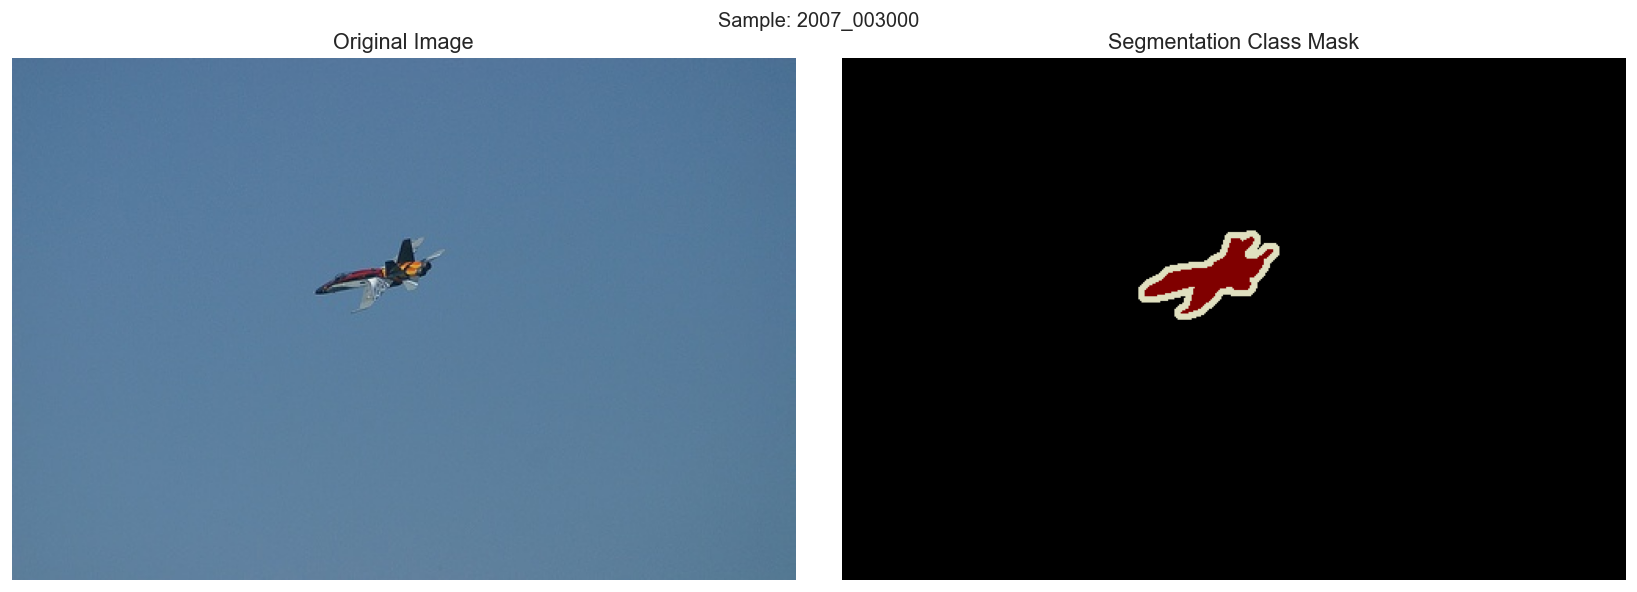

In [22]:
# Show one segmentation mask overlay
seg_sample = seg_files[0] if seg_files else None
if seg_sample:
    stem = os.path.splitext(os.path.basename(seg_sample))[0]
    img_path = os.path.join(IMG_DIR, stem + '.jpg')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    if os.path.exists(img_path):
        axes[0].imshow(Image.open(img_path))
        axes[0].set_title('Original Image', fontsize=13)
        axes[0].axis('off')

    mask = Image.open(seg_sample)
    axes[1].imshow(mask)
    axes[1].set_title('Segmentation Class Mask', fontsize=13)
    axes[1].axis('off')

    plt.suptitle(f'Sample: {stem}', fontsize=12)
    plt.tight_layout()
    plt.show()

## 12. Correlation & Co-occurrence Analysis

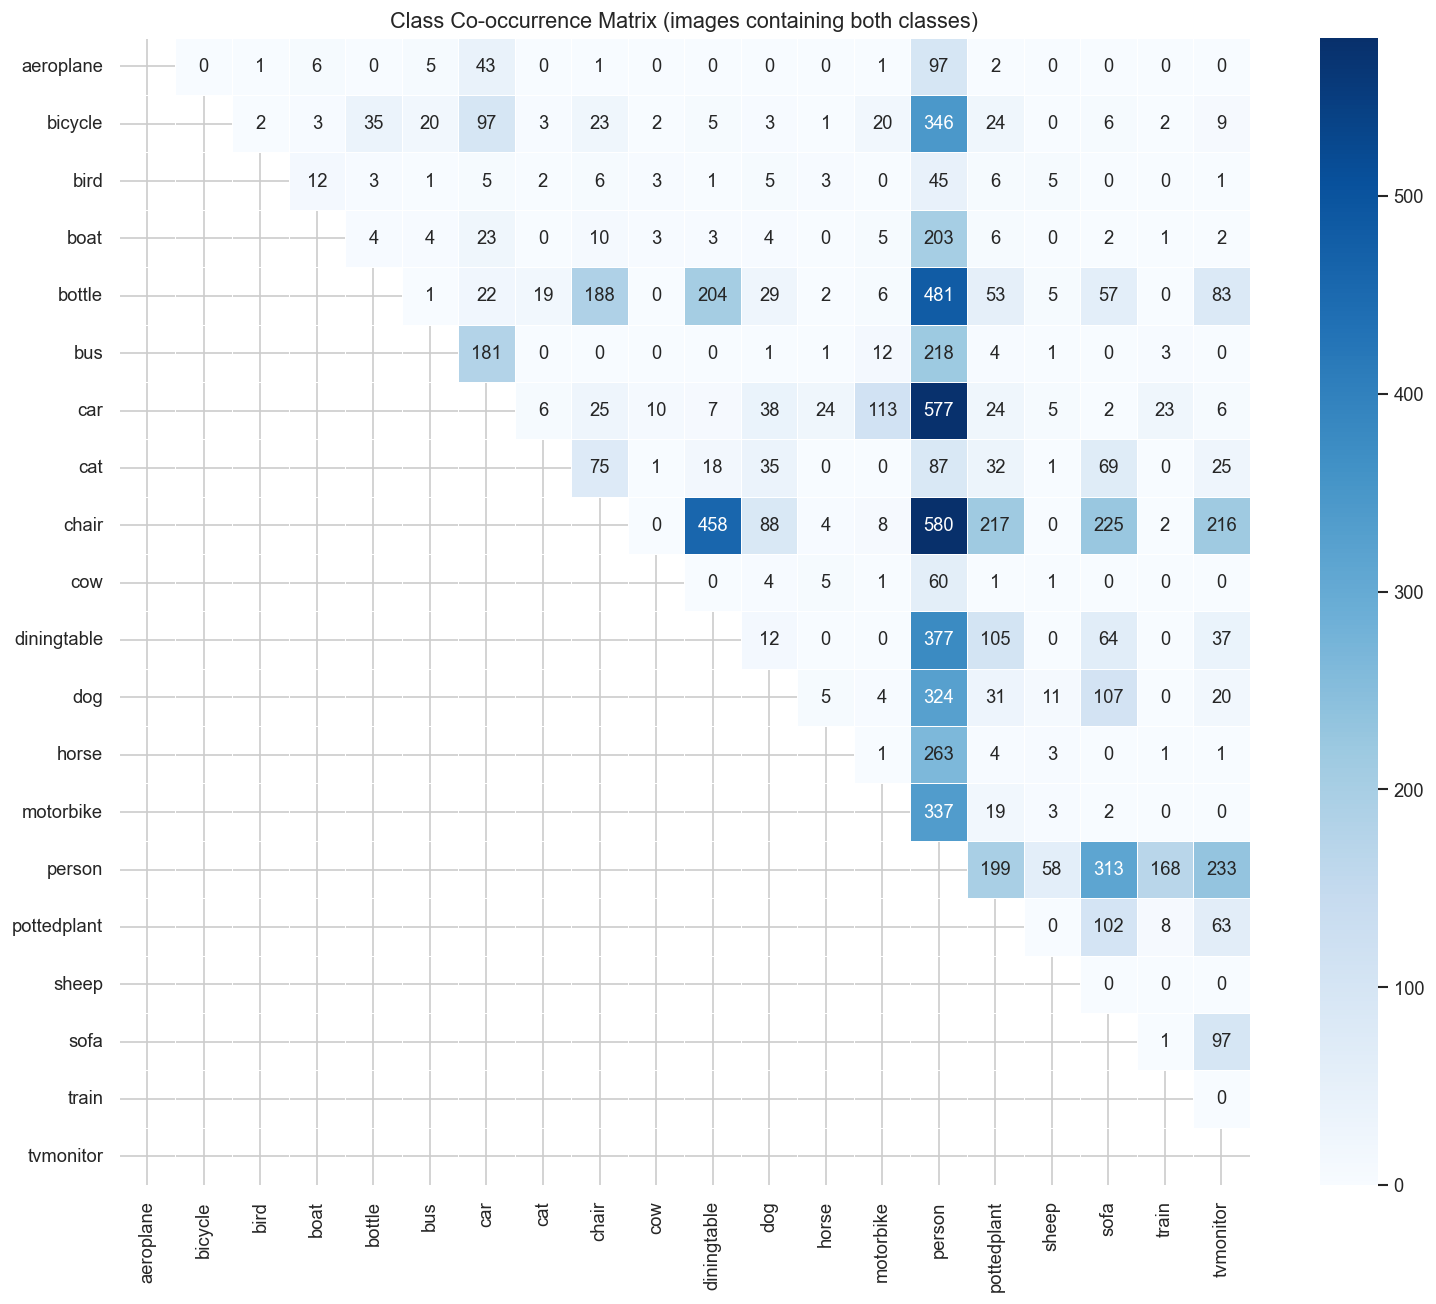

In [23]:
# Class co-occurrence: how often two classes appear in the same image
img_classes = df.groupby('filename')['label'].apply(set)
cooc = pd.DataFrame(0, index=VOC_CLASSES, columns=VOC_CLASSES)

for cls_set in img_classes:
    cls_list = [c for c in cls_set if c in VOC_CLASSES]
    for i, a in enumerate(cls_list):
        for b in cls_list[i:]:
            cooc.loc[a, b] += 1
            if a != b:
                cooc.loc[b, a] += 1

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(cooc, dtype=bool), k=1)
sns.heatmap(cooc, annot=True, fmt='d', cmap='Blues',
            linewidths=0.3, ax=ax, mask=~mask + np.eye(len(VOC_CLASSES), dtype=bool))
ax.set_title('Class Co-occurrence Matrix (images containing both classes)', fontsize=13)
plt.tight_layout()
plt.show()

## 13. Colour / Brightness Statistics (sample)

Reading pixel stats: 100%|███████████████████████████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 394.20it/s]


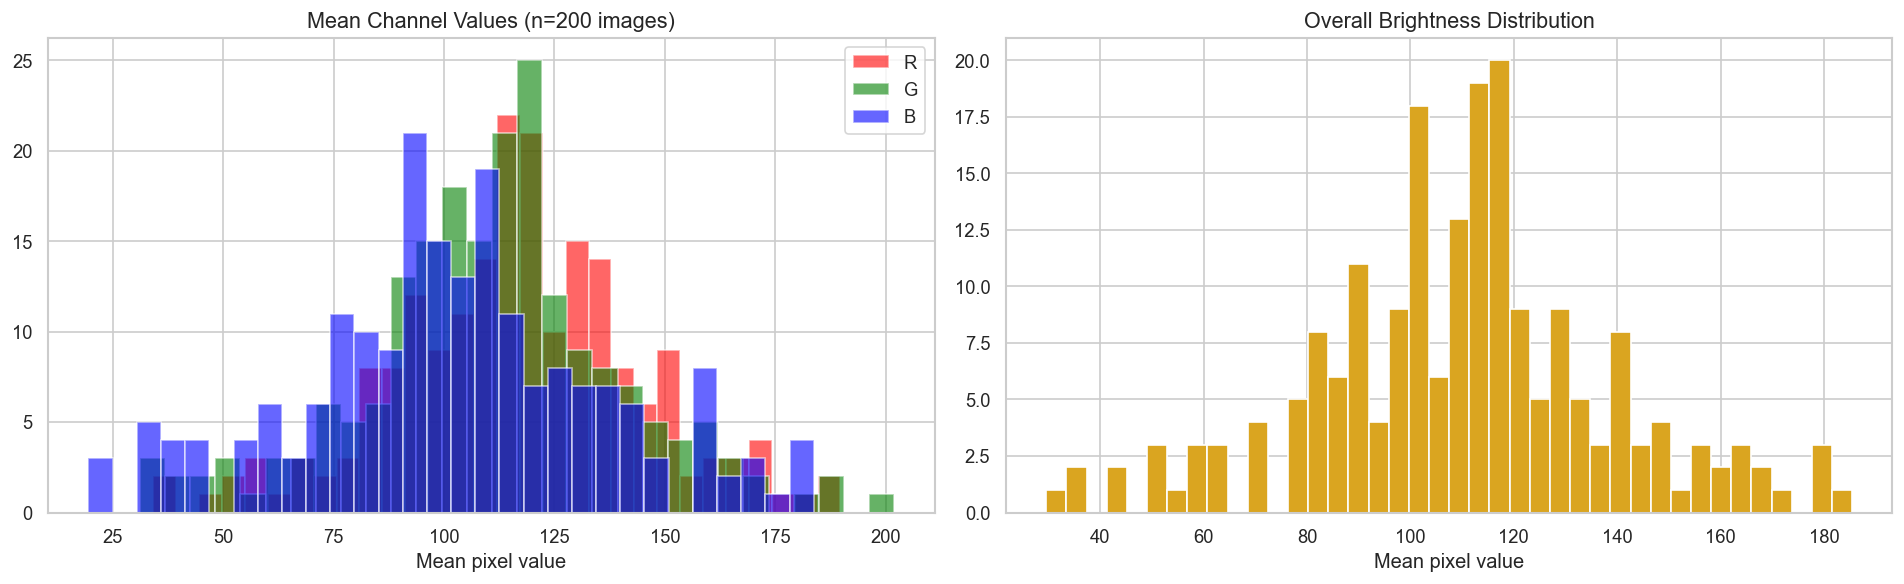

Dataset mean (R, G, B): (116.5, 111.2, 102.4)
Dataset std  (R, G, B): (28.0,  29.9,  34.3)


In [24]:
N_SAMPLE = 200
sample_imgs = np.random.choice(img_files, min(N_SAMPLE, len(img_files)), replace=False)

mean_r, mean_g, mean_b, brightness = [], [], [], []

for p in tqdm(sample_imgs, desc='Reading pixel stats'):
    arr = np.array(Image.open(p).convert('RGB'), dtype=np.float32)
    mean_r.append(arr[:,:,0].mean())
    mean_g.append(arr[:,:,1].mean())
    mean_b.append(arr[:,:,2].mean())
    brightness.append(arr.mean())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(mean_r, bins=30, alpha=0.6, color='red',   label='R')
axes[0].hist(mean_g, bins=30, alpha=0.6, color='green', label='G')
axes[0].hist(mean_b, bins=30, alpha=0.6, color='blue',  label='B')
axes[0].set_title(f'Mean Channel Values (n={N_SAMPLE} images)', fontsize=13)
axes[0].set_xlabel('Mean pixel value')
axes[0].legend()

axes[1].hist(brightness, bins=40, color='goldenrod', edgecolor='white')
axes[1].set_title('Overall Brightness Distribution', fontsize=13)
axes[1].set_xlabel('Mean pixel value')

plt.tight_layout()
plt.show()

print(f'Dataset mean (R, G, B): ({np.mean(mean_r):.1f}, {np.mean(mean_g):.1f}, {np.mean(mean_b):.1f})')
print(f'Dataset std  (R, G, B): ({np.std(mean_r):.1f},  {np.std(mean_g):.1f},  {np.std(mean_b):.1f})')

## 14. Summary & Recommendations

In [25]:
print('=' * 65)
print('          PASCAL VOC 2012 — EDA SUMMARY')
print('=' * 65)

print(f'\n📦 Dataset Size')
print(f'   Total images          : {df["filename"].nunique():,}')
print(f'   Total object instances: {len(df):,}')
print(f'   Classes               : {df["label"].nunique()}')

print(f'\n⚠️  Data Quality')
total_missing = df.isnull().sum().sum()
print(f'   Missing values        : {total_missing}')
print(f'   Invalid BB (w/h ≤ 0) : {bad_w + bad_h}')
print(f'   Out-of-bounds BB      : {len(oob)}')
print(f'   Difficult objects     : {df["difficult"].sum():,} '
      f'({df["difficult"].mean()*100:.1f}%)')
print(f'   Truncated objects     : {df["truncated"].sum():,} '
      f'({df["truncated"].mean()*100:.1f}%)')
print(f'   Occluded objects      : {df["occluded"].sum():,} '
      f'({df["occluded"].mean()*100:.1f}%)')

print(f'\n📊 Class Imbalance')
most   = class_counts.idxmax()
least  = class_counts.idxmin()
print(f'   Most common class     : {most} ({class_counts[most]:,} instances)')
print(f'   Least common class    : {least} ({class_counts[least]:,} instances)')
print(f'   Imbalance ratio       : {imbalance_ratio:.1f}x')

print(f'\n📐 Image Resolution')
print(f'   Width  range          : {img_meta["img_w"].min():.0f} – {img_meta["img_w"].max():.0f} px')
print(f'   Height range          : {img_meta["img_h"].min():.0f} – {img_meta["img_h"].max():.0f} px')
print(f'   Aspect ratio range    : {img_meta["aspect_ratio"].min():.2f} – {img_meta["aspect_ratio"].max():.2f}')

print(f'\n💡 Recommendations')
print('   1. Resize images to a fixed resolution (e.g. 416×416 or 640×640)')
print('      and normalise pixel values to [0,1] before training.')
print('   2. Filter out or down-weight "difficult" objects during training.')
print('   3. Address class imbalance with oversampling (rare classes),')
print('      weighted loss, or focal loss.')
print('   4. Clip bounding boxes to image boundaries to remove OOB errors.')
print('   5. Use multi-scale augmentation to handle the wide range of BB sizes.')
print('   6. Consider mixup / mosaic augmentation to improve small-class recall.')
print('=' * 65)

          PASCAL VOC 2012 — EDA SUMMARY

📦 Dataset Size
   Total images          : 17,125
   Total object instances: 40,138
   Classes               : 20

⚠️  Data Quality
   Missing values        : 0
   Invalid BB (w/h ≤ 0) : 0
   Out-of-bounds BB      : 0
   Difficult objects     : 4,462 (11.1%)
   Truncated objects     : 17,599 (43.8%)
   Occluded objects      : 13,299 (33.1%)

📊 Class Imbalance
   Most common class     : person (17,401 instances)
   Least common class    : bus (685 instances)
   Imbalance ratio       : 25.4x

📐 Image Resolution
   Width  range          : 142 – 500 px
   Height range          : 71 – 500 px
   Aspect ratio range    : 0.28 – 7.04

💡 Recommendations
   1. Resize images to a fixed resolution (e.g. 416×416 or 640×640)
      and normalise pixel values to [0,1] before training.
   2. Filter out or down-weight "difficult" objects during training.
   3. Address class imbalance with oversampling (rare classes),
      weighted loss, or focal loss.
   4. Clip b

# Feature Extraction

In [26]:
# ── Build numeric feature matrix from parsed annotation DataFrame ──────────
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from skrebate import ReliefF

# Features available per object instance
FEATURE_COLS = [
    'img_w', 'img_h', 'img_area',
    'bb_w', 'bb_h', 'bb_area', 'bb_rel_area',
    'aspect_ratio', 'bb_aspect',
    'difficult', 'truncated', 'occluded'
]

feat_df = df[FEATURE_COLS + ['label']].dropna().copy()

# Encode target label as integer
le = LabelEncoder()
feat_df['label_enc'] = le.fit_transform(feat_df['label'])

X = feat_df[FEATURE_COLS].values.astype(np.float32)
y = feat_df['label_enc'].values

# Scale features (needed for ReliefF and PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Feature matrix shape : {X.shape}')
print(f'Classes              : {list(le.classes_)}')

Feature matrix shape : (40138, 12)
Classes              : ['aeroplane', 'bicycle', 'bird', 'boat', 'bottle', 'bus', 'car', 'cat', 'chair', 'cow', 'diningtable', 'dog', 'horse', 'motorbike', 'person', 'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor']


Correlation with target label (|r| ranked):
bb_aspect      -0.2818
bb_h            0.1549
bb_w           -0.0641
aspect_ratio   -0.0454
img_h           0.0393
img_area        0.0287
img_w          -0.0261
bb_area         0.0226
bb_rel_area     0.0208
difficult      -0.0193
truncated       0.0089
occluded       -0.0008


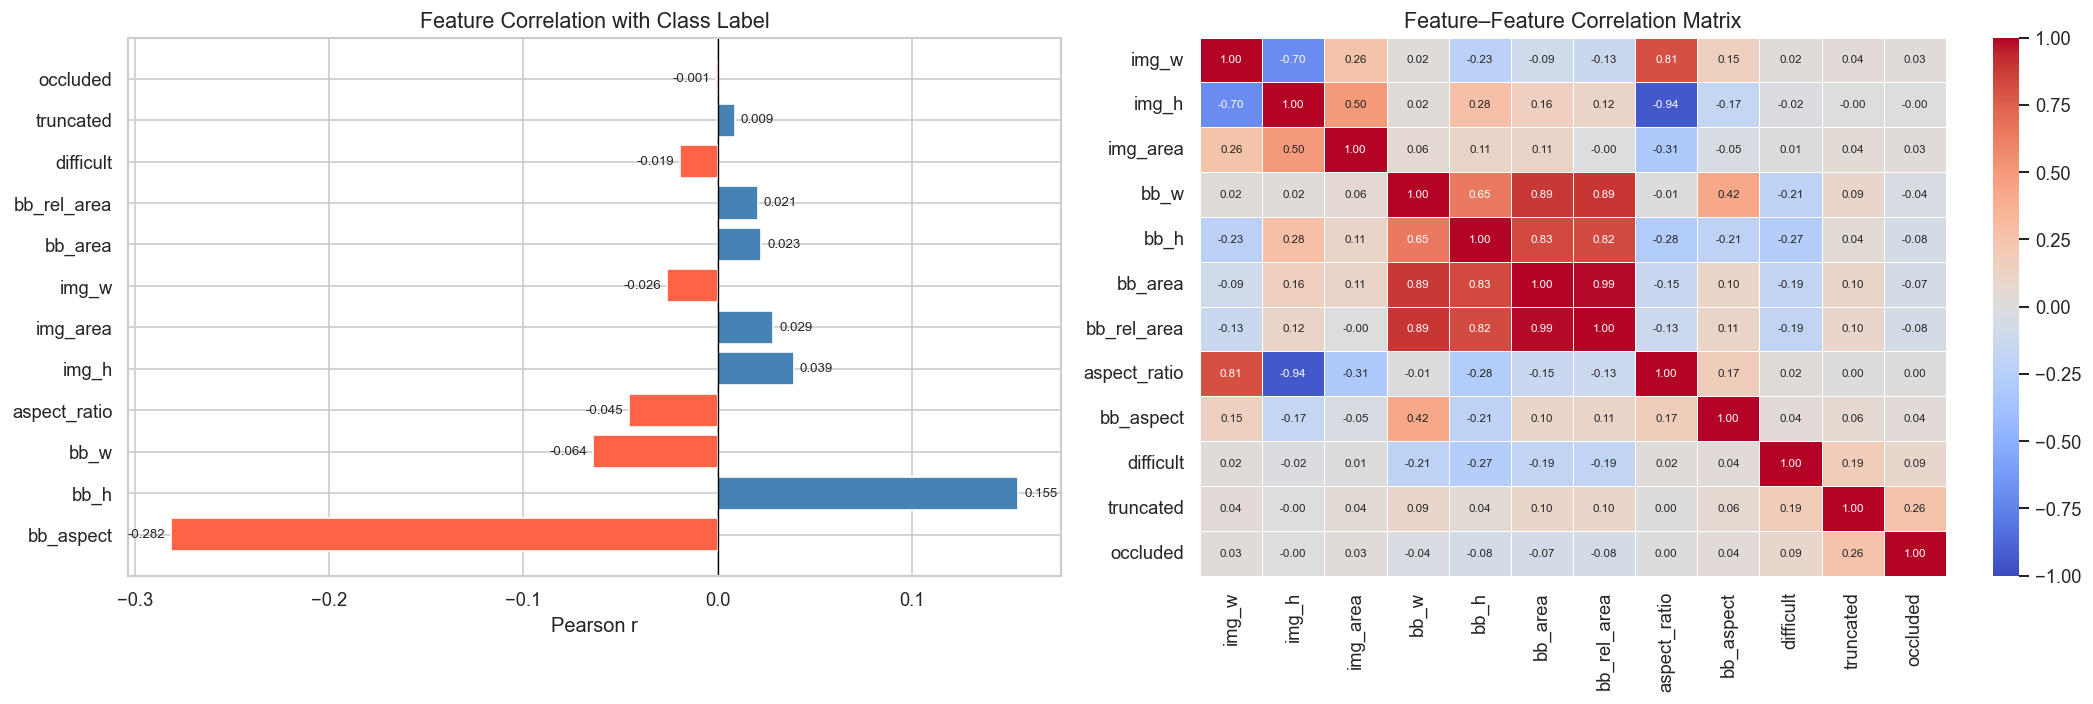


Highly correlated feature pairs (|r| > 0.85):
  img_h  ↔  aspect_ratio  :  r = -0.942
  bb_w  ↔  bb_area  :  r = 0.891
  bb_w  ↔  bb_rel_area  :  r = 0.891
  bb_area  ↔  bb_rel_area  :  r = 0.987


In [27]:
# ── Correlation-Based Feature Evaluation ──────────────────────────────────
# Pearson correlation of each feature with the encoded label

corr_with_target = (
    pd.DataFrame(X_scaled, columns=FEATURE_COLS)
    .apply(lambda col: np.corrcoef(col, y)[0, 1])
    .rename('Pearson r')
    .sort_values(key=abs, ascending=False)
)

print('Correlation with target label (|r| ranked):')
print(corr_with_target.round(4).to_string())

# Feature–feature correlation heatmap
feat_corr_matrix = pd.DataFrame(X_scaled, columns=FEATURE_COLS).corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar: correlation with target
colors = ['tomato' if v < 0 else 'steelblue' for v in corr_with_target.values]
axes[0].barh(corr_with_target.index, corr_with_target.values, color=colors)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_title('Feature Correlation with Class Label', fontsize=13)
axes[0].set_xlabel('Pearson r')
for i, v in enumerate(corr_with_target.values):
    axes[0].text(v + (0.003 if v >= 0 else -0.003), i,
                 f'{v:.3f}', va='center',
                 ha='left' if v >= 0 else 'right', fontsize=8)

# Heatmap: feature–feature correlations
sns.heatmap(feat_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=axes[1], vmin=-1, vmax=1,
            annot_kws={'size': 7})
axes[1].set_title('Feature–Feature Correlation Matrix', fontsize=13)

plt.tight_layout()
plt.show()

# Flag highly correlated feature pairs (|r| > 0.85)
print('\nHighly correlated feature pairs (|r| > 0.85):')
high_corr = []
for i in range(len(FEATURE_COLS)):
    for j in range(i+1, len(FEATURE_COLS)):
        r = feat_corr_matrix.iloc[i, j]
        if abs(r) > 0.85:
            high_corr.append((FEATURE_COLS[i], FEATURE_COLS[j], round(r, 3)))
if high_corr:
    for a, b, r in high_corr:
        print(f'  {a}  ↔  {b}  :  r = {r}')
else:
    print('  None found.')

ReliefF scores (n_samples=3000):
bb_aspect       0.01796
bb_h            0.01753
img_area        0.00759
bb_rel_area     0.00562
bb_w            0.00532
bb_area         0.00480
difficult      -0.00007
truncated      -0.00017
occluded       -0.00057
img_h          -0.00353
img_w          -0.00410
aspect_ratio   -0.00428


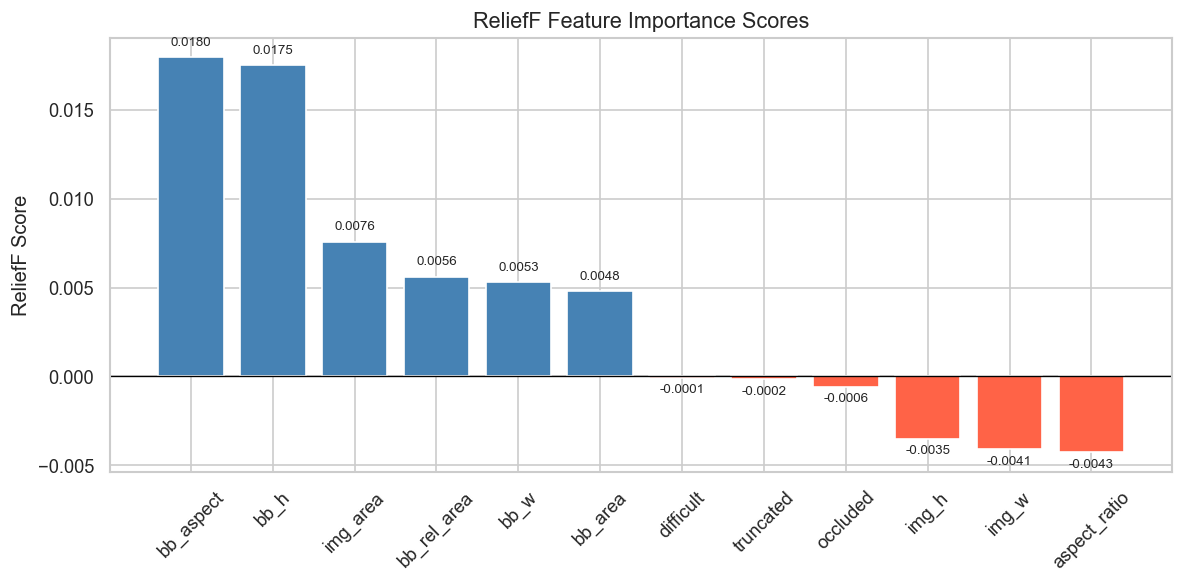

In [28]:
# ── ReliefF Feature Evaluation ────────────────────────────────────────────
# ReliefF scores features by how well they distinguish between
# near-neighbour samples of different classes.
# Using a subsample for speed (ReliefF is O(n²) in samples).

N_RELIEF = min(3000, len(X_scaled))
idx = np.random.choice(len(X_scaled), N_RELIEF, replace=False)
X_r, y_r = X_scaled[idx], y[idx]

relief = ReliefF(n_neighbors=10, n_features_to_select=len(FEATURE_COLS))
relief.fit(X_r, y_r)

relief_scores = pd.Series(relief.feature_importances_,
                           index=FEATURE_COLS,
                           name='ReliefF Score').sort_values(ascending=False)

print(f'ReliefF scores (n_samples={N_RELIEF}):')
print(relief_scores.round(5).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['tomato' if v < 0 else 'steelblue' for v in relief_scores.values]
bars = ax.bar(relief_scores.index, relief_scores.values, color=colors, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ReliefF Feature Importance Scores', fontsize=13)
ax.set_ylabel('ReliefF Score')
ax.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, relief_scores.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.0005 if v >= 0 else -0.001),
            f'{v:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Information Gain scores:
bb_aspect       0.30708
bb_w            0.14734
bb_area         0.11316
bb_rel_area     0.11257
bb_h            0.10690
aspect_ratio    0.09662
img_area        0.08470
img_h           0.07349
img_w           0.02932
truncated       0.02832
occluded        0.02813
difficult       0.01198


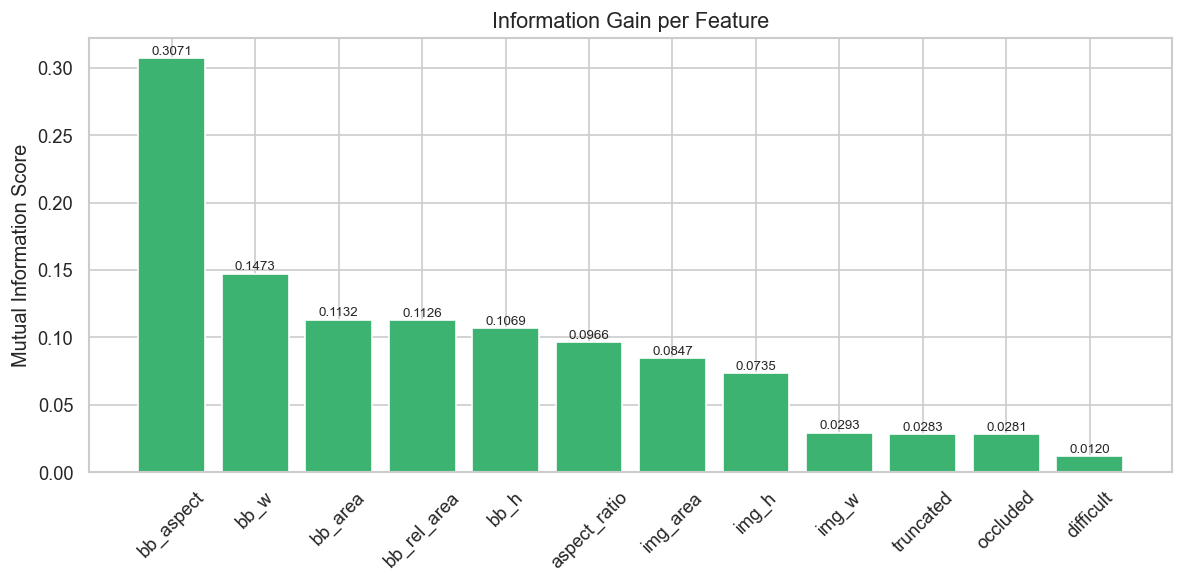


Average rank across all 3 methods (lower = more important):
bb_aspect        1.00
bb_h             3.00
bb_w             3.33
img_area         5.33
bb_area          5.67
bb_rel_area      5.67
aspect_ratio     7.33
img_h            7.67
img_w            9.00
difficult        9.67
truncated        9.67
occluded        10.67


In [29]:
# ── Information Gain (Mutual Information) Feature Evaluation ───────────────
# sklearn's mutual_info_classif estimates I(feature ; label).
# Higher = more relevant to the target class.

ig_scores = mutual_info_classif(X_scaled, y,
                                 discrete_features=False,
                                 random_state=42)

ig_series = pd.Series(ig_scores, index=FEATURE_COLS,
                       name='Info Gain').sort_values(ascending=False)

print('Information Gain scores:')
print(ig_series.round(5).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ig_series.index, ig_series.values,
              color='mediumseagreen', edgecolor='white')
ax.set_title('Information Gain per Feature', fontsize=13)
ax.set_ylabel('Mutual Information Score')
ax.tick_params(axis='x', rotation=45)
for bar, v in zip(bars, ig_series.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.0005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

# Combined ranking table
ranking = pd.DataFrame({
    'Correlation |r|' : corr_with_target.abs(),
    'ReliefF Score'   : relief_scores,
    'Info Gain'       : ig_series,
}).rank(ascending=False).mean(axis=1).sort_values()

print('\nAverage rank across all 3 methods (lower = more important):')
print(ranking.round(2).to_string())

Components to explain 95% variance : 7

Explained variance per component:
  PC 1   31.94%   cumulative:  31.94%
  PC 2   22.12%   cumulative:  54.06%
  PC 3   11.89%   cumulative:  65.94%
  PC 4   10.19%   cumulative:  76.13%
  PC 5    8.87%   cumulative:  85.00%
  PC 6    7.41%   cumulative:  92.41%
  PC 7    5.51%   cumulative:  97.92%
  PC 8    1.15%   cumulative:  99.08%
  PC 9    0.47%   cumulative:  99.55%
  PC10    0.35%   cumulative:  99.90%
  PC11    0.06%   cumulative:  99.96%
  PC12    0.04%   cumulative: 100.00%


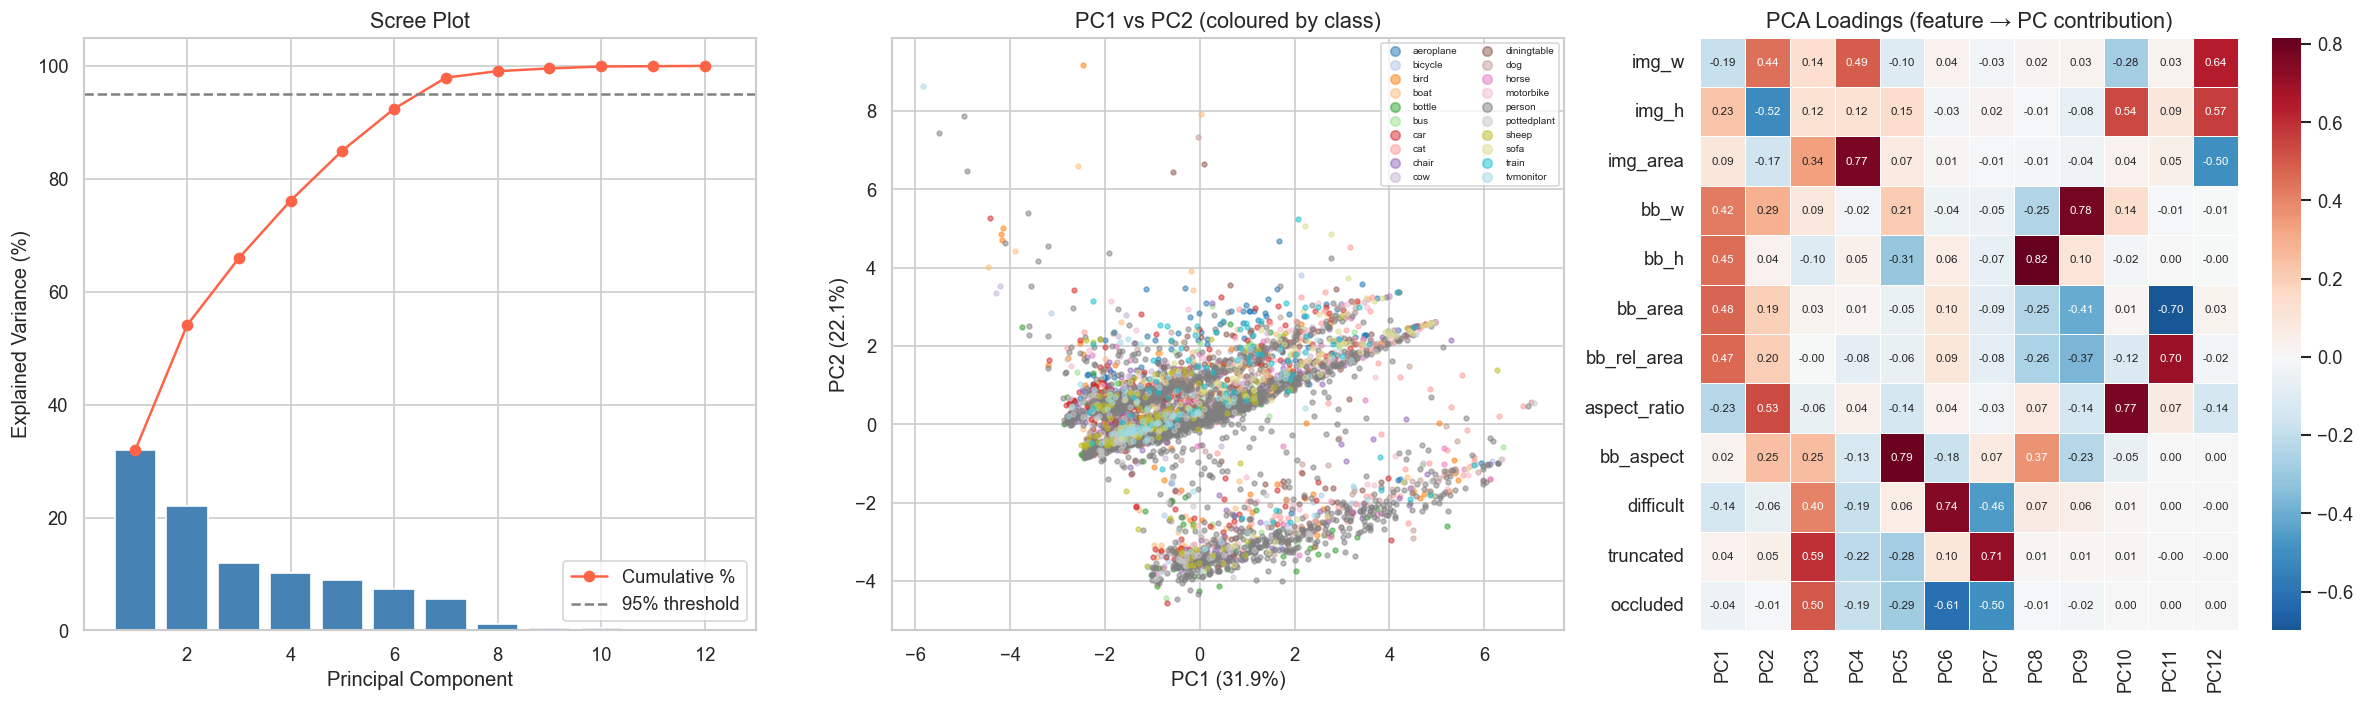


Top contributing features per principal component:
  PC1: bb_area, bb_rel_area, bb_h
  PC2: aspect_ratio, img_h, img_w
  PC3: truncated, occluded, difficult
  PC4: img_area, img_w, truncated


In [30]:
# ── Principal Component Analysis ───────────────────────────────────────────
pca = PCA(n_components=len(FEATURE_COLS))
X_pca = pca.fit_transform(X_scaled)

explained       = pca.explained_variance_ratio_
cumulative_var  = np.cumsum(explained)
n_95            = np.searchsorted(cumulative_var, 0.95) + 1

print(f'Components to explain 95% variance : {n_95}')
print(f'\nExplained variance per component:')
for i, (ev, cum) in enumerate(zip(explained, cumulative_var)):
    print(f'  PC{i+1:2d}  {ev*100:6.2f}%   cumulative: {cum*100:6.2f}%')

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Scree plot
axes[0].bar(range(1, len(explained)+1), explained * 100,
            color='steelblue', edgecolor='white')
axes[0].plot(range(1, len(explained)+1), cumulative_var * 100,
             'o-', color='tomato', label='Cumulative %')
axes[0].axhline(95, color='grey', linestyle='--', label='95% threshold')
axes[0].set_title('Scree Plot', fontsize=13)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].legend()

# PC1 vs PC2 scatter coloured by class
scatter_limit = min(5000, len(X_pca))
idx_s = np.random.choice(len(X_pca), scatter_limit, replace=False)
unique_labels = np.unique(y[idx_s])
palette = plt.cm.tab20(np.linspace(0, 1, len(unique_labels)))
for lbl, col in zip(unique_labels, palette):
    mask = y[idx_s] == lbl
    axes[1].scatter(X_pca[idx_s][mask, 0], X_pca[idx_s][mask, 1],
                    s=8, alpha=0.5, color=col,
                    label=le.inverse_transform([lbl])[0])
axes[1].set_title('PC1 vs PC2 (coloured by class)', fontsize=13)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}%)')
axes[1].legend(fontsize=6, ncol=2, markerscale=2)

# Loadings heatmap (contribution of original features to each PC)
loadings = pd.DataFrame(
    pca.components_.T,
    index=FEATURE_COLS,
    columns=[f'PC{i+1}' for i in range(len(FEATURE_COLS))]
)
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.4, ax=axes[2],
            annot_kws={'size': 7})
axes[2].set_title('PCA Loadings (feature → PC contribution)', fontsize=13)

plt.tight_layout()
plt.show()

print(f'\nTop contributing features per principal component:')
for pc in loadings.columns[:4]:
    top = loadings[pc].abs().sort_values(ascending=False).head(3)
    print(f'  {pc}: {", ".join(top.index.tolist())}')

Feature Importance Summary (all methods):
              Correlation |r|  ReliefF Score  Info Gain  PCA PC1 Loading
bb_aspect              0.2818         0.0180     0.3071           0.0245
bb_w                   0.0641         0.0053     0.1473           0.4194
bb_area                0.0226         0.0048     0.1132           0.4754
bb_rel_area            0.0208         0.0056     0.1126           0.4699
bb_h                   0.1549         0.0175     0.1069           0.4495
aspect_ratio           0.0454        -0.0043     0.0966           0.2314
img_area               0.0287         0.0076     0.0847           0.0926
img_h                  0.0393        -0.0035     0.0735           0.2335
img_w                  0.0261        -0.0041     0.0293           0.1865
truncated              0.0089        -0.0002     0.0283           0.0396
occluded               0.0008        -0.0006     0.0281           0.0435
difficult              0.0193        -0.0001     0.0120           0.1405


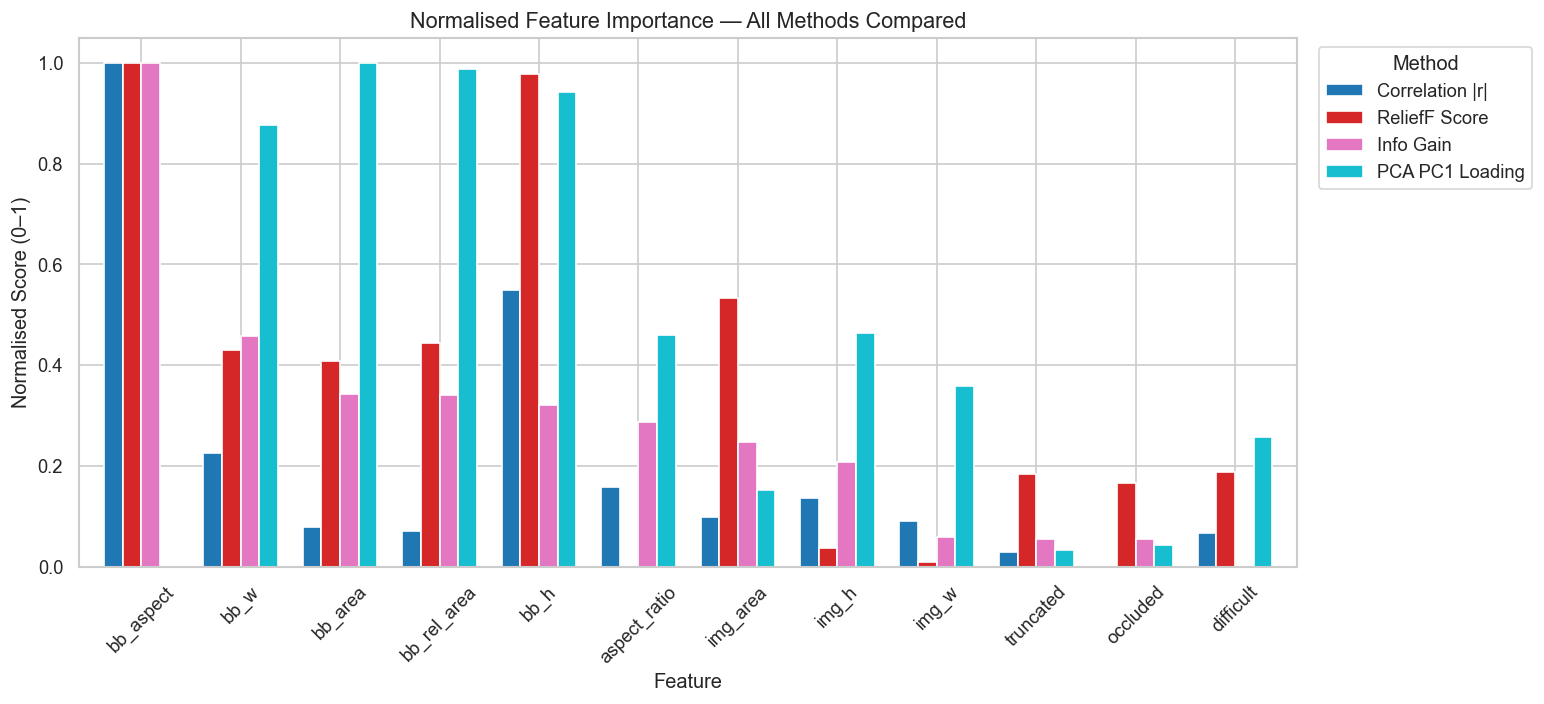

In [31]:
# ── Summary: All Methods Side-by-Side ─────────────────────────────────────
summary = pd.DataFrame({
    'Correlation |r|' : corr_with_target.abs().round(4),
    'ReliefF Score'   : relief_scores.round(4),
    'Info Gain'       : ig_series.round(4),
    'PCA PC1 Loading' : loadings['PC1'].abs().round(4),
}).sort_values('Info Gain', ascending=False)

print('Feature Importance Summary (all methods):')
print(summary.to_string())

fig, ax = plt.subplots(figsize=(13, 6))
summary_norm = (summary - summary.min()) / (summary.max() - summary.min())
summary_norm.plot(kind='bar', ax=ax, width=0.75,
                  colormap='tab10', edgecolor='white')
ax.set_title('Normalised Feature Importance — All Methods Compared', fontsize=13)
ax.set_ylabel('Normalised Score (0–1)')
ax.set_xlabel('Feature')
ax.tick_params(axis='x', rotation=45)
ax.legend(title='Method', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ML Model

In [32]:
import os
os.environ['TORCH_HOME'] = '.venv/torch_models'

In [33]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import os
from tqdm import tqdm

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cpu')   # Mac GPU if available, else CPU
print(f'Using device: {device}')

# Load pretrained ResNet50 — strip final classification layer
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
resnet.fc = torch.nn.Identity()   # output 2048-dim embedding instead of 1000-class logits
resnet = resnet.to(device)
resnet.eval()

# Standard ImageNet normalisation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print('ResNet50 feature extractor ready ✅')
print('Embedding size: 2048 per crop')

Using device: mps
ResNet50 feature extractor ready ✅
Embedding size: 2048 per crop


In [34]:
FEATURE_COLS_BBOX = [
    'img_w', 'img_h', 'img_area',
    'bb_w', 'bb_h', 'bb_area', 'bb_rel_area',
    'aspect_ratio', 'bb_aspect',
    'difficult', 'truncated', 'occluded'
]

extract_df = df[FEATURE_COLS_BBOX + ['filename','label','xmin','ymin','xmax','ymax']]\
             .dropna().copy()

# Balanced subsample (CNN extraction is slower)
MAX_SAMPLES = 10000
extract_df = extract_df.groupby('label', group_keys=False)\
                       .apply(lambda g: g.sample(
                           min(len(g), MAX_SAMPLES // 20),
                           random_state=42))\
                       .reset_index(drop=True)

print(f'Extracting embeddings for {len(extract_df):,} instances...')

iter_df = extract_df.rename(columns={'label': 'cls'})

embeddings, labels, skipped = [], [], 0

base_df = df[['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'label']]\
            .dropna().copy().reset_index(drop=True)

# Sample per class without groupby
PER_CLASS = 500   # 500 × 20 classes = 10,000 total
sampled_parts = []
for cls in base_df['label'].unique():
    cls_df = base_df[base_df['label'] == cls]
    sampled_parts.append(cls_df.sample(min(len(cls_df), PER_CLASS),
                                       random_state=42))
clean_df = pd.concat(sampled_parts).reset_index(drop=True)

print(f'Columns : {clean_df.columns.tolist()}')
print(f'Rows    : {len(clean_df):,}')

rows_list = clean_df.to_dict('records')

with torch.no_grad():
    for row in tqdm(rows_list, total=len(rows_list),
                    desc='CNN embedding extraction'):

        img_path = os.path.join(IMG_DIR, row['filename'])
        if not os.path.exists(img_path):
            skipped += 1
            continue

        img = Image.open(img_path).convert('RGB')

        x1 = max(0, int(row['xmin']))
        y1 = max(0, int(row['ymin']))
        x2 = min(img.width,  int(row['xmax']))
        y2 = min(img.height, int(row['ymax']))

        if x2 <= x1 or y2 <= y1:
            skipped += 1
            continue

        crop = img.crop((x1, y1, x2, y2))
        tensor = transform(crop).unsqueeze(0).to(device)
        embedding = resnet(tensor).squeeze().cpu().numpy()

        embeddings.append(embedding)
        labels.append(row['label'])

X_cnn = np.array(embeddings, dtype=np.float32)
y_cnn = np.array(labels)

print(f'\nEmbedding matrix : {X_cnn.shape}')
print(f'Skipped          : {skipped}')
print(f'Classes          : {np.unique(y_cnn)}')

Extracting embeddings for 10,000 instances...
Columns : ['filename', 'xmin', 'ymin', 'xmax', 'ymax', 'label']
Rows    : 10,000


CNN embedding extraction: 100%|███████████████████████████████████████████████████████████████████████| 10000/10000 [02:54<00:00, 57.15it/s]


Embedding matrix : (10000, 2048)
Skipped          : 0
Classes          : ['aeroplane' 'bicycle' 'bird' 'boat' 'bottle' 'bus' 'car' 'cat' 'chair'
 'cow' 'diningtable' 'dog' 'horse' 'motorbike' 'person' 'pottedplant'
 'sheep' 'sofa' 'train' 'tvmonitor']


## Model Training


Training 3 models on 2048 features...

--- Training Logistic Regression ---
Training time: 1.17 seconds
Test Accuracy: 0.8725 | Weighted F1: 0.8722

Per-Class Report — Logistic Regression:
              precision    recall  f1-score   support

   aeroplane       0.98      0.96      0.97       100
     bicycle       0.91      0.90      0.90       100
        bird       0.88      0.92      0.90       100
        boat       0.83      0.85      0.84       100
      bottle       0.83      0.88      0.85       100
         bus       0.94      0.89      0.91       100
         car       0.81      0.84      0.82       100
         cat       0.94      0.96      0.95       100
       chair       0.71      0.64      0.67       100
         cow       0.86      0.86      0.86       100
 diningtable       0.77      0.82      0.80       100
         dog       0.92      0.95      0.94       100
       horse       0.95      0.93      0.94       100
   motorbike       0.94      0.88      0.91       100


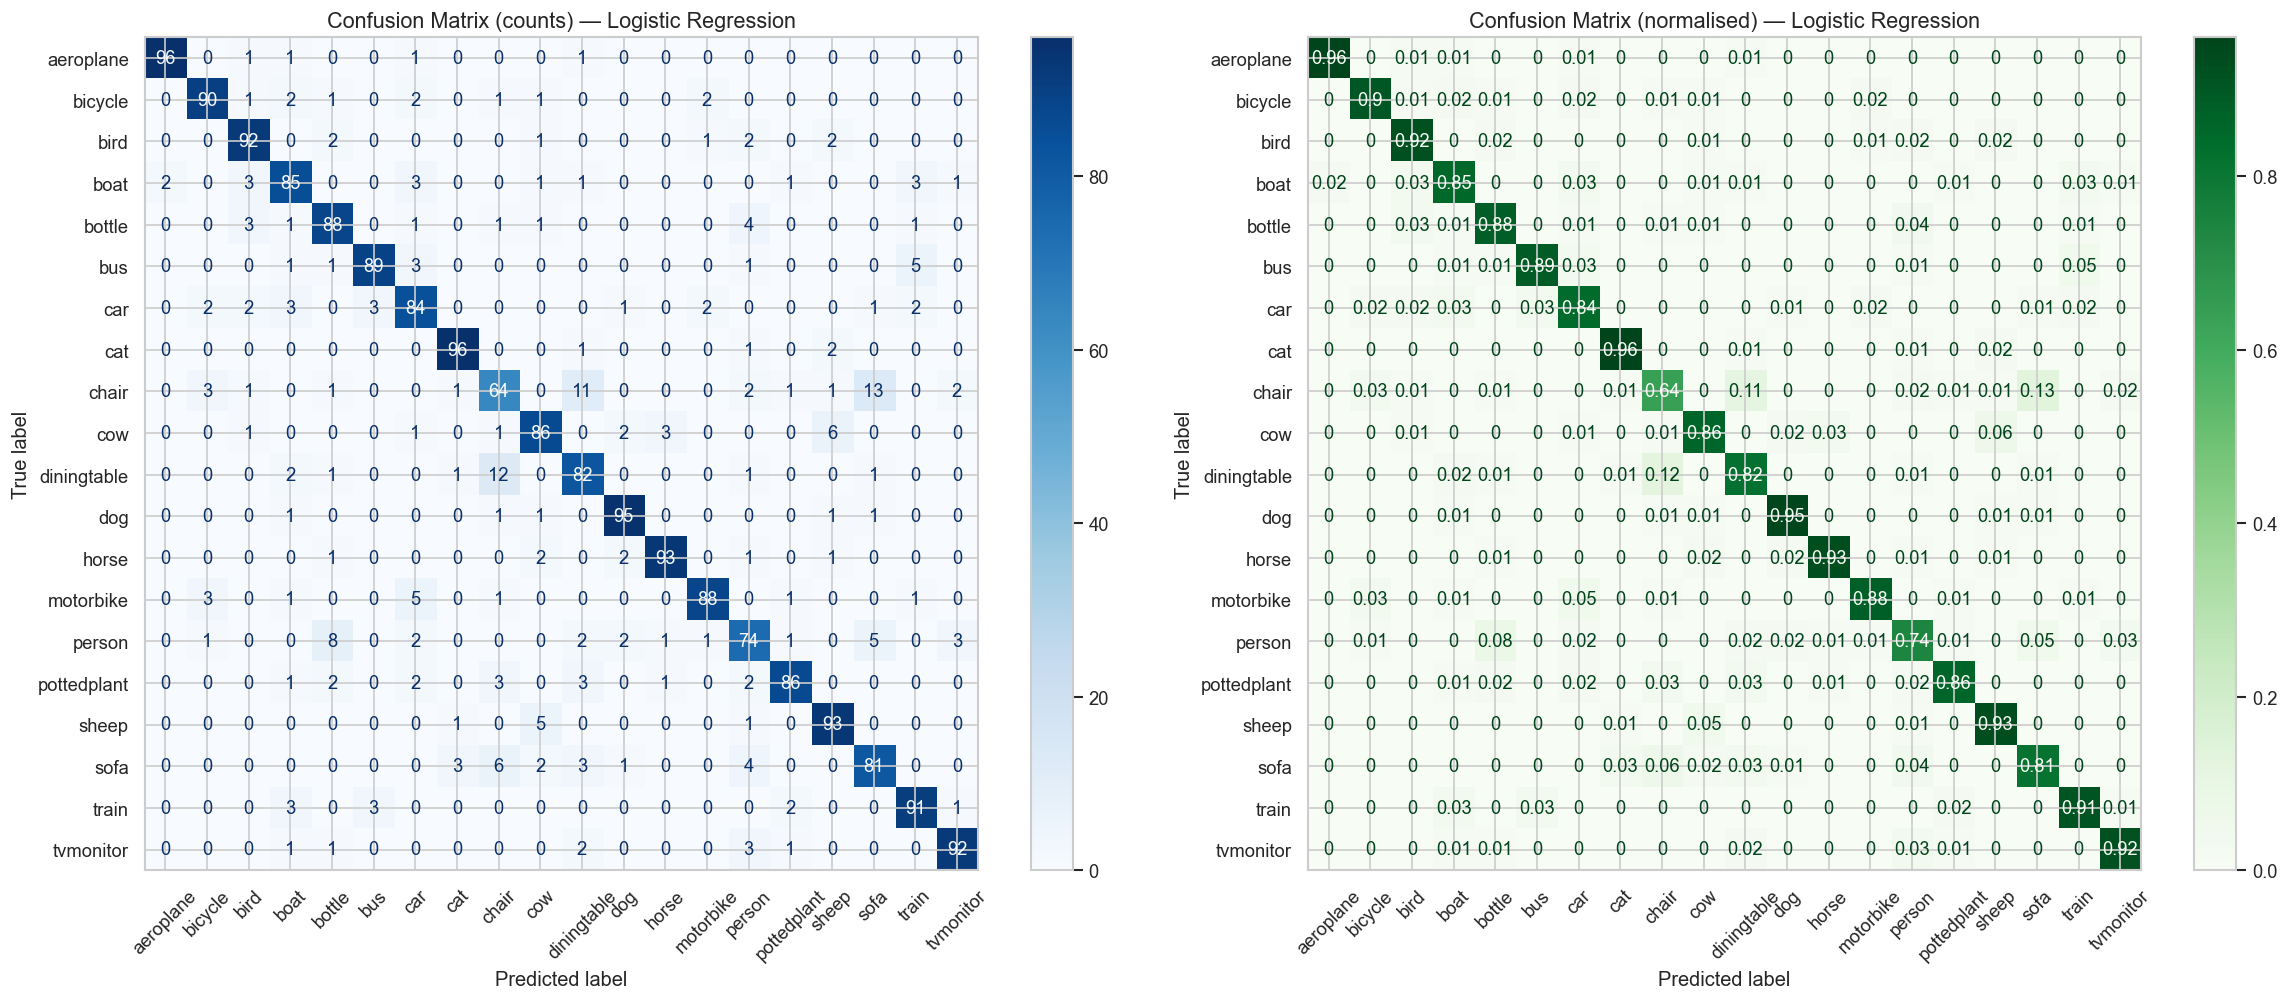

--- Training Random Forest ---
Training time: 1.03 seconds
Test Accuracy: 0.8170 | Weighted F1: 0.8139

Per-Class Report — Random Forest:
              precision    recall  f1-score   support

   aeroplane       0.97      0.85      0.90       100
     bicycle       0.90      0.86      0.88       100
        bird       0.86      0.92      0.89       100
        boat       0.67      0.87      0.76       100
      bottle       0.73      0.85      0.78       100
         bus       0.95      0.83      0.89       100
         car       0.80      0.74      0.77       100
         cat       0.90      0.91      0.91       100
       chair       0.62      0.47      0.53       100
         cow       0.76      0.72      0.74       100
 diningtable       0.77      0.69      0.73       100
         dog       0.84      0.90      0.87       100
       horse       0.86      0.88      0.87       100
   motorbike       0.86      0.88      0.87       100
      person       0.76      0.51      0.61       1

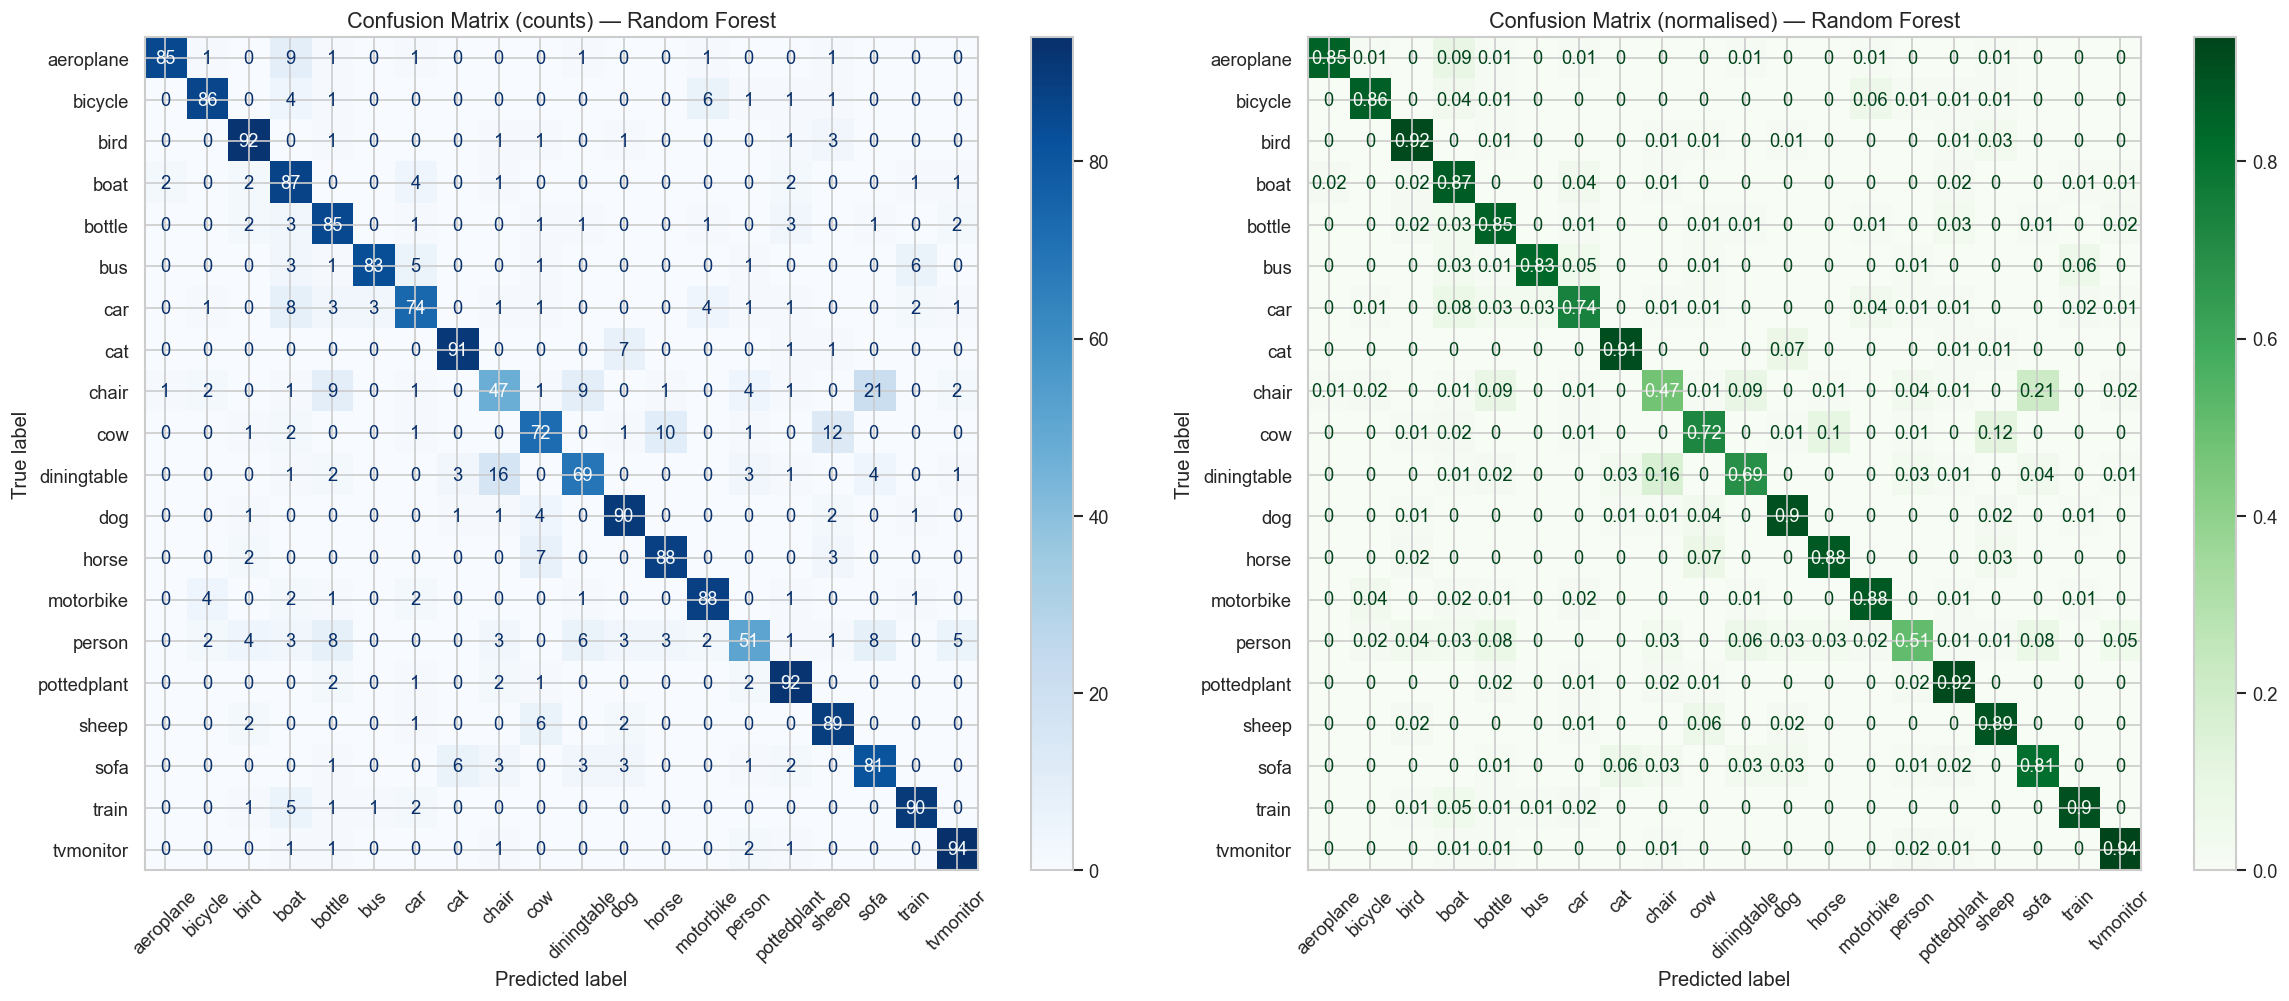

--- Training Decision Tree ---
Training time: 7.40 seconds
Test Accuracy: 0.4220 | Weighted F1: 0.4118

Per-Class Report — Decision Tree:
              precision    recall  f1-score   support

   aeroplane       0.94      0.79      0.86       100
     bicycle       0.85      0.70      0.77       100
        bird       0.00      0.00      0.00       100
        boat       0.00      0.00      0.00       100
      bottle       0.09      0.93      0.16       100
         bus       0.91      0.70      0.79       100
         car       0.33      0.01      0.02       100
         cat       0.91      0.74      0.82       100
       chair       0.33      0.01      0.02       100
         cow       0.72      0.67      0.69       100
 diningtable       0.20      0.01      0.02       100
         dog       0.00      0.00      0.00       100
       horse       0.80      0.65      0.72       100
   motorbike       0.89      0.73      0.80       100
      person       0.27      0.04      0.07       1

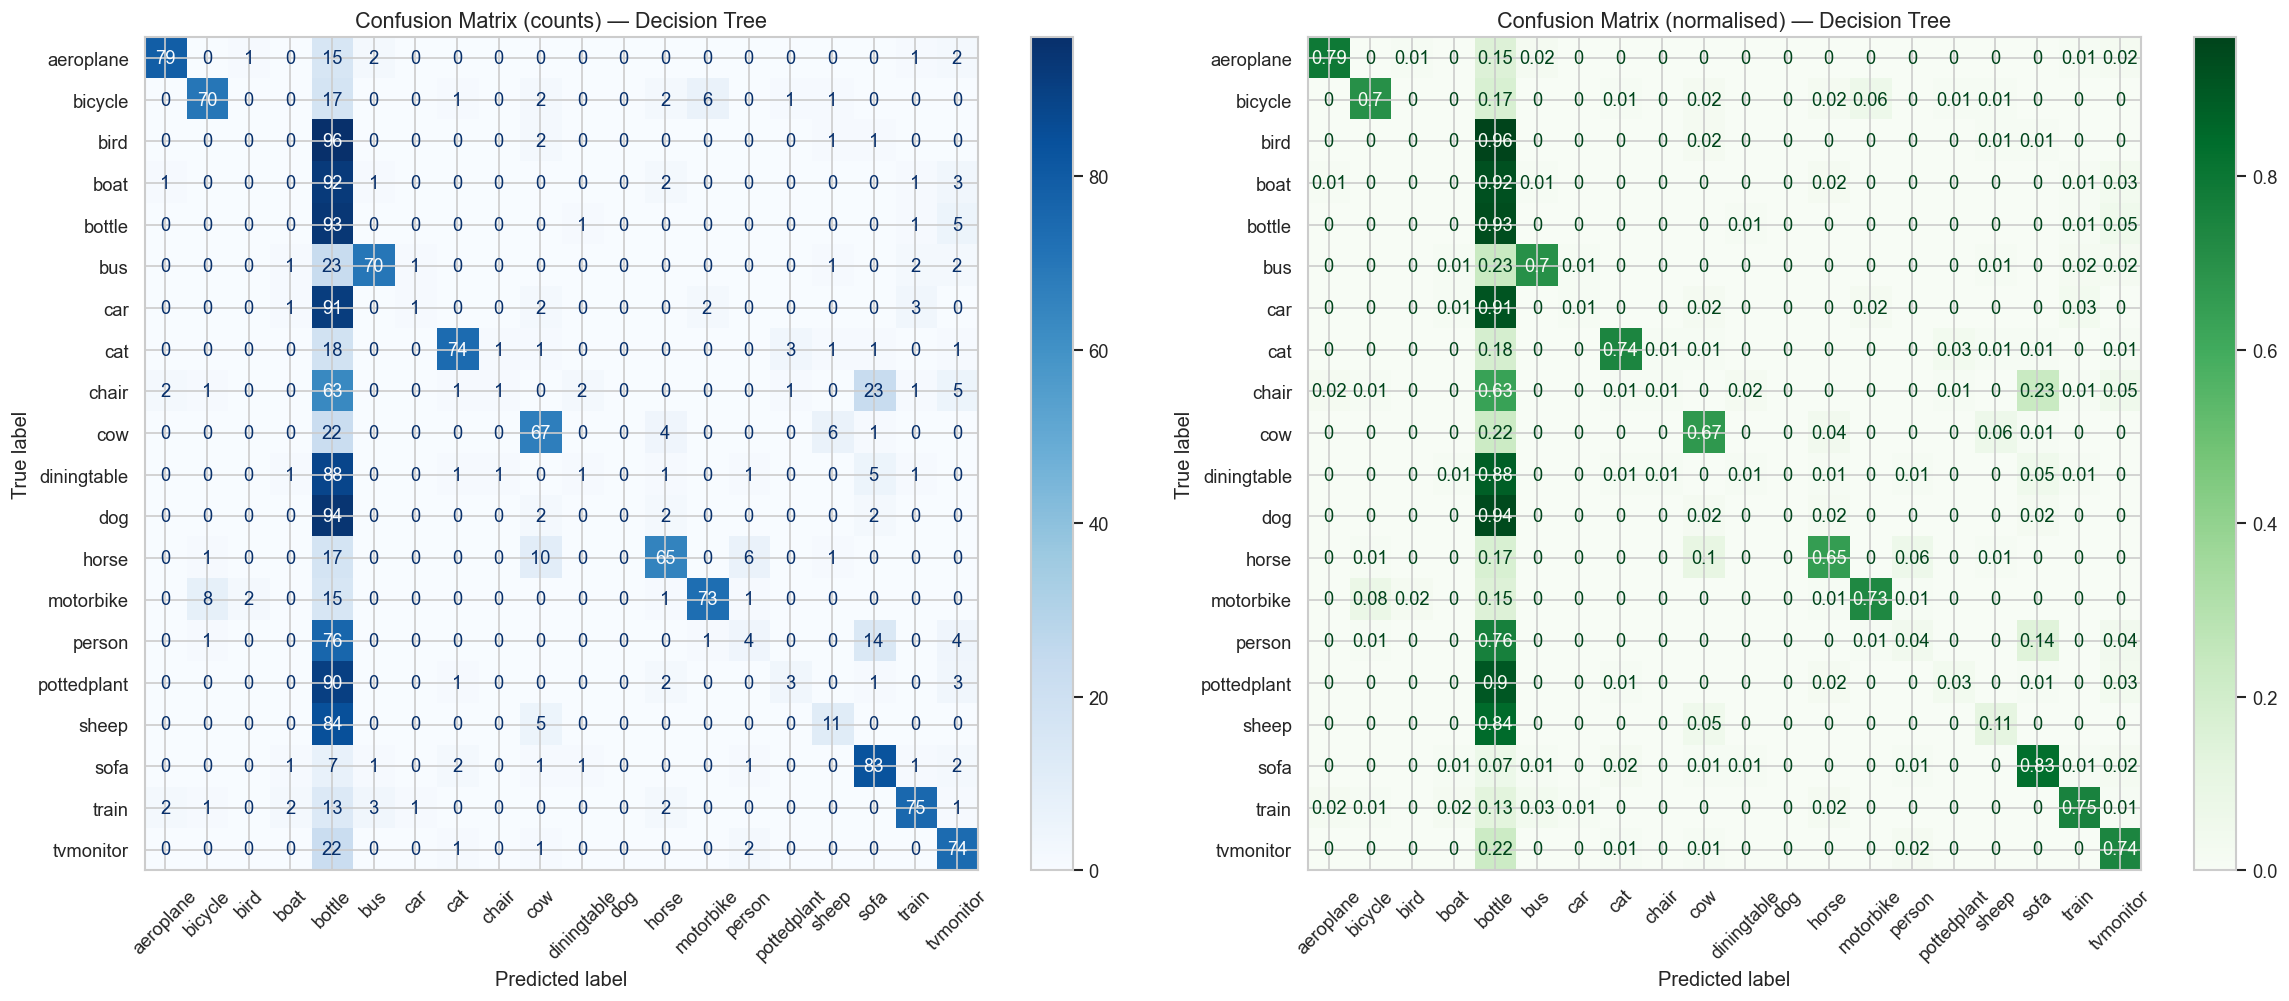

In [35]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import time
import pandas as pd
import numpy as np

# 1. Prepare Data
le_cnn = LabelEncoder()
y_enc  = le_cnn.fit_transform(y_cnn)

X_train, X_test, y_train, y_test = train_test_split(
    X_cnn, y_enc, test_size=0.2, stratify=y_enc, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 2. Define Models
models_to_train = {
    'Logistic Regression': LogisticRegression(max_iter=500, solver='lbfgs', 
                                              class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=10, 
                                            class_weight='balanced', n_jobs=-1, 
                                            random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, class_weight='balanced', 
                                            random_state=42)
}

trained_models = {}
y_preds = {}
y_probs = {}

print(f"Training {len(models_to_train)} models on {X_train_sc.shape[1]} features...\n")

for name, model in models_to_train.items():
    print(f"--- Training {name} ---")
    t0 = time.time()
    model.fit(X_train_sc, y_train)
    print(f"Training time: {time.time() - t0:.2f} seconds")
    
    trained_models[name] = model
    y_preds[name] = model.predict(X_test_sc)
    if hasattr(model, "predict_proba"):
        y_probs[name] = model.predict_proba(X_test_sc)
        
    acc = accuracy_score(y_test, y_preds[name])
    f1 = f1_score(y_test, y_preds[name], average='weighted')
    print(f"Test Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}\n")
    
    print(f"Per-Class Report — {name}:")
    print(classification_report(y_test, y_preds[name], target_names=le_cnn.classes_, zero_division=0))
    
    # Confusion Matrices
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, y_preds[name]),
        display_labels=le_cnn.classes_
    ).plot(ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation=45)
    axes[0].set_title(f'Confusion Matrix (counts) — {name}', fontsize=13)
    
    cm_norm = confusion_matrix(y_test, y_preds[name]).astype(float)
    cm_norm /= cm_norm.sum(axis=1, keepdims=True)
    ConfusionMatrixDisplay(
        cm_norm.round(2), display_labels=le_cnn.classes_
    ).plot(ax=axes[1], cmap='Greens', colorbar=True, xticks_rotation=45)
    axes[1].set_title(f'Confusion Matrix (normalised) — {name}', fontsize=13)
    
    plt.tight_layout()
    plt.show()

## Experiment 6: Hypothesis Testing against Baseline


In [36]:
from scipy import stats

# ── Step 1: State the Hypothesis ──────────────────────────────────────────
# H₀ : Model accuracy = 0.05 (random chance for 20 classes)
# H₁ : Model accuracy > 0.05 (model learns meaningful patterns)
# Significance level: α = 0.05

# ── Step 2: Formulate Analysis Plan ───────────────────────────────────────
# Use 10-fold stratified cross-validation to get accuracy scores per fold
# Apply one-sample t-test comparing observed accuracy against baseline (0.05)

# ── Step 3: Collect Sample Data ───────────────────────────────────────────
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

model_cv = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(max_iter=1000, C=1.0,
                                  class_weight='balanced', random_state=42))
])

cv_scores_exp6 = cross_val_score(model_cv, X_cnn, y_enc,
                             cv=cv, scoring='accuracy', n_jobs=-1)

print('CV Accuracy per fold:', np.round(cv_scores_exp6, 4))
print(f'Mean: {cv_scores_exp6.mean():.4f} ± {cv_scores_exp6.std():.4f}')

# ── Step 4: Analyze Sample Data ───────────────────────────────────────────
baseline = 0.05
t_stat, p_val = stats.ttest_1samp(cv_scores_exp6, baseline)
p_one_tailed = p_val / 2   # one-tailed since H₁ is directional (>)
print(f'\nOne-sample t-test vs baseline ({baseline}):')
print(f't={t_stat:.4f}, p (one-tailed)={p_one_tailed:.6f}')

# ── Step 5: Interpret Results ─────────────────────────────────────────────
alpha = 0.05
if p_one_tailed < alpha and cv_scores_exp6.mean() > baseline:
    print('→ REJECT H₀ : Model performs significantly better than random chance')
else:
    print('→ FAIL TO REJECT H₀ : No significant difference from random chance')

# ── Step 6: Estimate Type I & Type II Errors ──────────────────────────────
# Type I (α) = 0.05 — probability of rejecting H₀ when it is actually true
# Type II (β) — estimated via power analysis
effect_size = (cv_scores_exp6.mean() - baseline) / cv_scores_exp6.std()
power = 1 - stats.t.cdf(stats.t.ppf(0.95, df=9) - effect_size * np.sqrt(10), df=9)
print(f'\nEffect size : {effect_size:.4f}')
print(f'Estimated power (1-β) : {power:.4f}')
print(f'Type I  Error (α)     : {alpha:.4f}')
print(f'Type II Error (β)     : {1-power:.4f}')


CV Accuracy per fold: [0.886 0.874 0.879 0.866 0.867 0.863 0.86  0.858 0.866 0.873]
Mean: 0.8692 ± 0.0083

One-sample t-test vs baseline (0.05):
t=295.9461, p (one-tailed)=0.000000
→ REJECT H₀ : Model performs significantly better than random chance

Effect size : 98.6487
Estimated power (1-β) : 1.0000
Type I  Error (α)     : 0.0500
Type II Error (β)     : 0.0000


## Gather CV Scores for Further Tests


In [37]:
print("Running 10-Fold CV to gather scores for further Hypothesis Testing...\n")

fold_scores = {}
for name, model in models_to_train.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()), 
        ('clf', model)
    ])
    # We use f1_weighted to evaluate performance across multiple classes
    scores = cross_val_score(pipe, X_cnn, y_enc, cv=cv, scoring='f1_weighted', n_jobs=-1)
    fold_scores[name] = scores

lr_scores = fold_scores['Logistic Regression']
rf_scores = fold_scores['Random Forest']
dt_scores = fold_scores['Decision Tree']

print("CV scores successfully gathered for all models.")


Running 10-Fold CV to gather scores for further Hypothesis Testing...

CV scores successfully gathered for all models.


## Paired T-Test


In [38]:
from scipy.stats import ttest_rel

# Paired T-Test (Logistic Regression vs Random Forest)
t_stat, p_val_t = ttest_rel(lr_scores, rf_scores)
print('=' * 50)
print('           PAIRED T-TEST (LR vs RF)')
print('=' * 50)
print(f'  t-statistic : {t_stat:.4f}')
print(f'  p-value     : {p_val_t:.4f}')
if p_val_t < 0.05:
    print('  → REJECT H₀: Significant difference between LR and RF')
else:
    print('  → FAIL TO REJECT H₀: No significant difference between LR and RF')


           PAIRED T-TEST (LR vs RF)
  t-statistic : 19.4518
  p-value     : 0.0000
  → REJECT H₀: Significant difference between LR and RF


## Chi-Square Test


In [39]:
from scipy.stats import chi2_contingency
from sklearn.metrics import confusion_matrix

# Chi-Square Test (Predicted vs Actual for Logistic Regression)
cm = confusion_matrix(y_test, y_preds['Logistic Regression'])
chi2, p_val_chi, dof, expected = chi2_contingency(cm)
print('=' * 50)
print('   CHI-SQUARE TEST (Predictions of Logistic Regression)')
print('=' * 50)
print(f'  Chi-square statistic : {chi2:.4f}')
print(f'  Degrees of freedom   : {dof}')
print(f'  p-value              : {p_val_chi:.6f}')
if p_val_chi < 0.05:
    print('  → REJECT H₀: Predicted and actual class distributions are NOT independent.')
else:
    print('  → FAIL TO REJECT H₀: Predicted and actual class distributions are independent.')


   CHI-SQUARE TEST (Predictions of Logistic Regression)
  Chi-square statistic : 28852.4727
  Degrees of freedom   : 361
  p-value              : 0.000000
  → REJECT H₀: Predicted and actual class distributions are NOT independent.


## Friedman Test


In [40]:
from scipy.stats import friedmanchisquare

# Friedman Test (Proper non-parametric test for multiple models on the same datasets)
stat_f, p_val_f = friedmanchisquare(lr_scores, rf_scores, dt_scores)
print('=' * 50)
print('             FRIEDMAN TEST RESULTS')
print('=' * 50)
print(f'  Chi-Square Statistic : {stat_f:.4f}')
print(f'  p-value              : {p_val_f:.6f}')
if p_val_f < 0.05:
    print('  → REJECT H₀: The models DO NOT perform equally.')
else:
    print('  → FAIL TO REJECT H₀: There is no significant difference.')


             FRIEDMAN TEST RESULTS
  Chi-Square Statistic : 20.0000
  p-value              : 0.000045
  → REJECT H₀: The models DO NOT perform equally.


## Wilcoxon Signed Rank Test


In [41]:
from scipy.stats import wilcoxon

# Wilcoxon Signed Rank Test (LR vs RF)
stat_w, p_val_w = wilcoxon(lr_scores, rf_scores)
print('=' * 50)
print('    WILCOXON SIGNED RANK TEST (LR vs RF)')
print('=' * 50)
print(f'  Statistic : {stat_w:.4f}')
print(f'  p-value   : {p_val_w:.4f}')
if p_val_w < 0.05:
    print('  → REJECT H₀: Significant difference between LR and RF')
else:
    print('  → FAIL TO REJECT H₀: No significant difference between LR and RF')


    WILCOXON SIGNED RANK TEST (LR vs RF)
  Statistic : 0.0000
  p-value   : 0.0020
  → REJECT H₀: Significant difference between LR and RF


## ANOVA Test


In [42]:
from scipy.stats import f_oneway

# ANOVA Test
stat_a, p_val_a = f_oneway(rf_scores, lr_scores, dt_scores)
print('=' * 50)
print('           ANOVA TEST RESULTS')
print('=' * 50)
print(f'  F-statistic : {stat_a:.4f}')
print(f'  p-value     : {p_val_a:.4f}')
if p_val_a < 0.05:
    print('  → REJECT H₀: Significant difference in mean F1 scores')
else:
    print('  → FAIL TO REJECT H₀: No significant difference in mean F1 scores')


           ANOVA TEST RESULTS
  F-statistic : 5667.7890
  p-value     : 0.0000
  → REJECT H₀: Significant difference in mean F1 scores


## Nemenyi Test


In [43]:
import scikit_posthocs as sp

# Nemenyi Post-Hoc Test
print('=' * 50)
print('        NEMENYI POST-HOC TEST RESULTS')
print('=' * 50)
data_matrix = pd.DataFrame(fold_scores)
try:
    nemenyi_result = sp.posthoc_nemenyi_friedman(data_matrix)
    print('p-value matrix:')
    print(nemenyi_result.round(4).to_string())
    print()
    for i in nemenyi_result.index:
        for j in nemenyi_result.columns:
            if i < j:
                p = nemenyi_result.loc[i, j]
                sig = 'SIGNIFICANT ✅' if p < 0.05 else 'not significant'
                print(f'  {i} vs {j}: p={p:.4f} → {sig}')
except Exception as e:
    print("Nemenyi test error:", e)


        NEMENYI POST-HOC TEST RESULTS
p-value matrix:
                     Logistic Regression  Random Forest  Decision Tree
Logistic Regression               1.0000         0.0653         0.0000
Random Forest                     0.0653         1.0000         0.0653
Decision Tree                     0.0000         0.0653         1.0000

  Logistic Regression vs Random Forest: p=0.0653 → not significant
  Decision Tree vs Logistic Regression: p=0.0000 → SIGNIFICANT ✅
  Decision Tree vs Random Forest: p=0.0653 → not significant


## Complete Evaluation and Performance Analysis


              FINAL MODEL PERFORMANCE ANALYSIS


,Accuracy,F1 Weighted,F1 Macro,Precision (W),Recall (W)
Model,,,,,
Logistic Regression,0.8725,0.8722,0.8722,0.8727,0.8725
Random Forest,0.8170,0.8139,0.8139,0.8183,0.8170
Decision Tree,0.4220,0.4118,0.4118,0.5180,0.4220



 Best Model: Logistic Regression  (F1=0.8722)

  Per-Class Report — Logistic Regression:
              precision    recall  f1-score   support

   aeroplane       0.98      0.96      0.97       100
     bicycle       0.91      0.90      0.90       100
        bird       0.88      0.92      0.90       100
        boat       0.83      0.85      0.84       100
      bottle       0.83      0.88      0.85       100
         bus       0.94      0.89      0.91       100
         car       0.81      0.84      0.82       100
         cat       0.94      0.96      0.95       100
       chair       0.71      0.64      0.67       100
         cow       0.86      0.86      0.86       100
 diningtable       0.77      0.82      0.80       100
         dog       0.92      0.95      0.94       100
       horse       0.95      0.93      0.94       100
   motorbike       0.94      0.88      0.91       100
      person       0.77      0.74      0.76       100
 pottedplant       0.92      0.86      0.89  

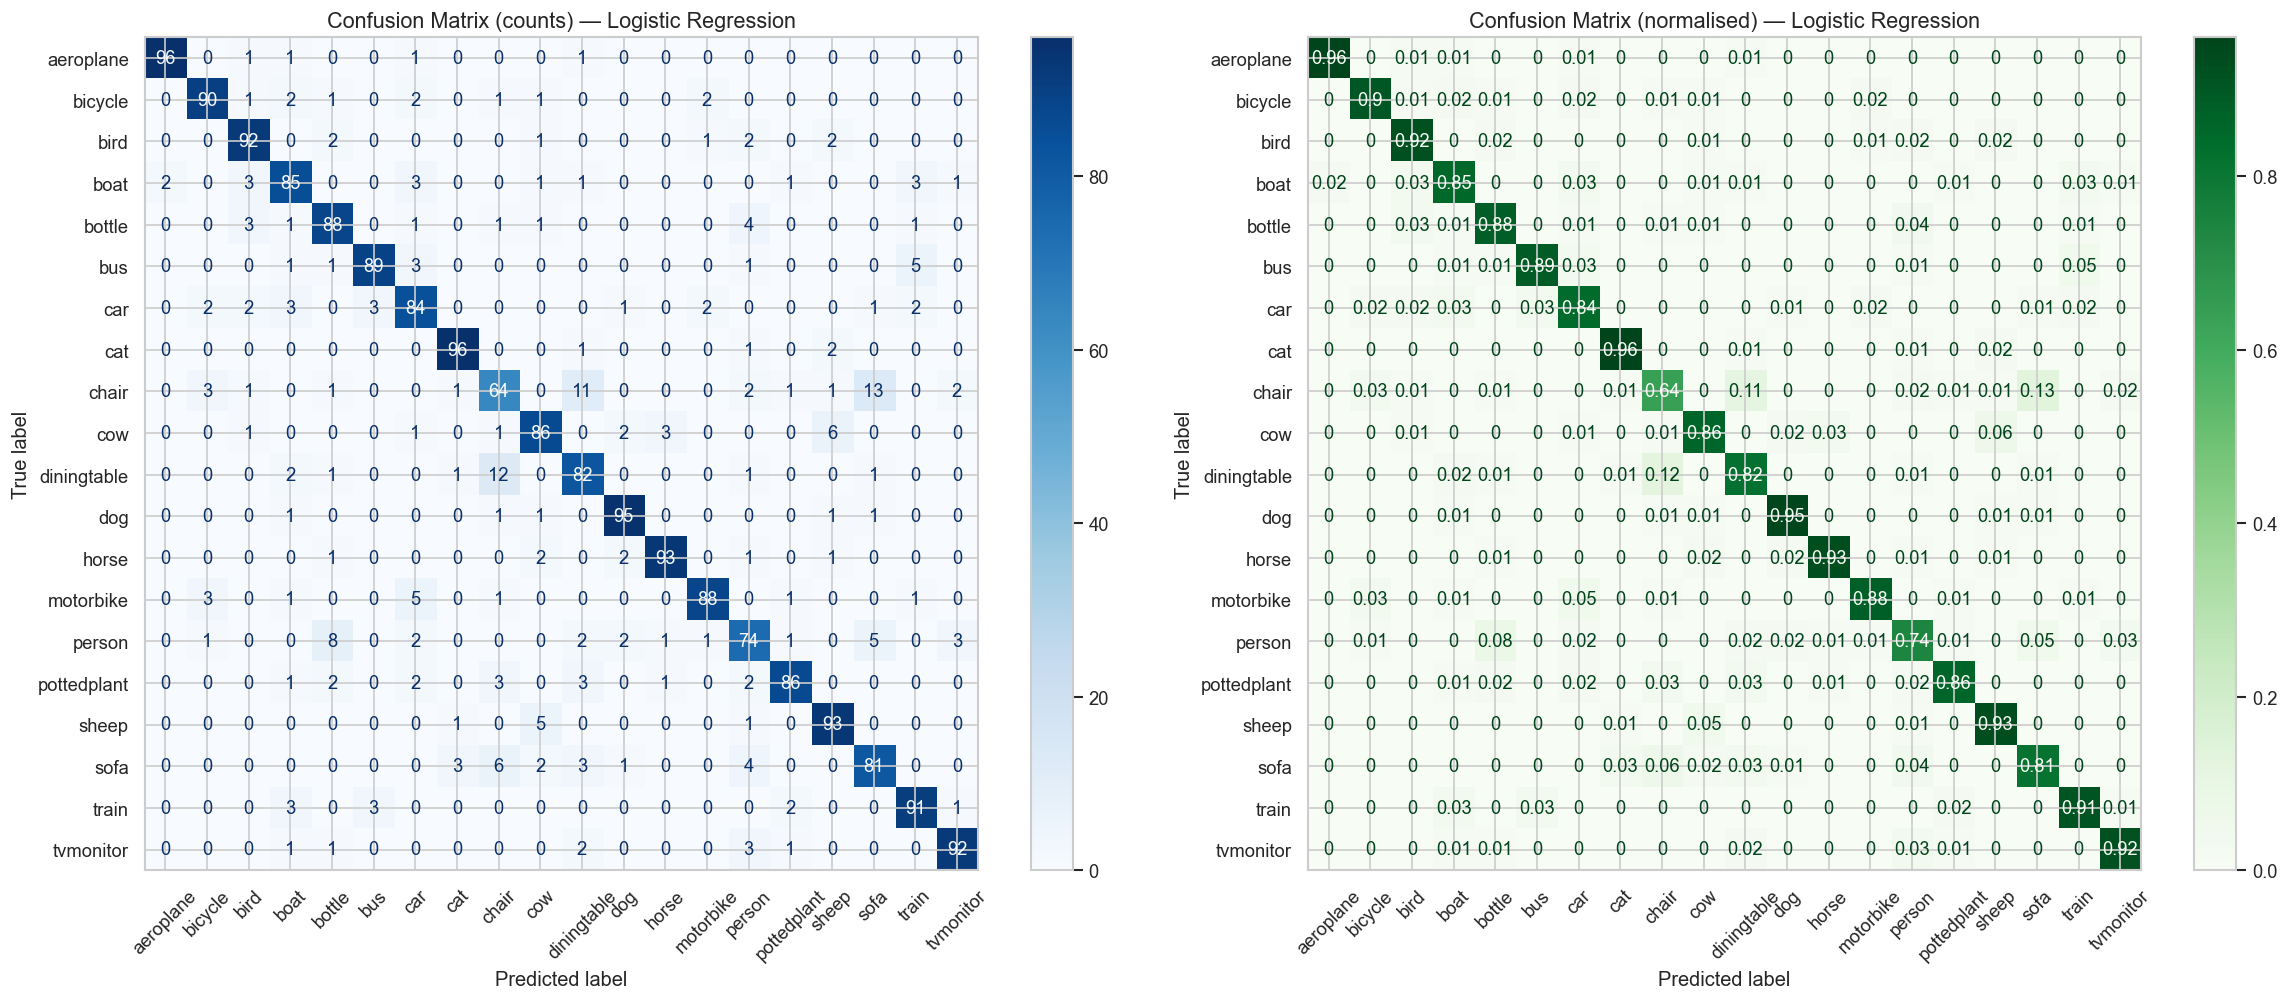


Macro AUC (OvR) — Logistic Regression: 0.9930


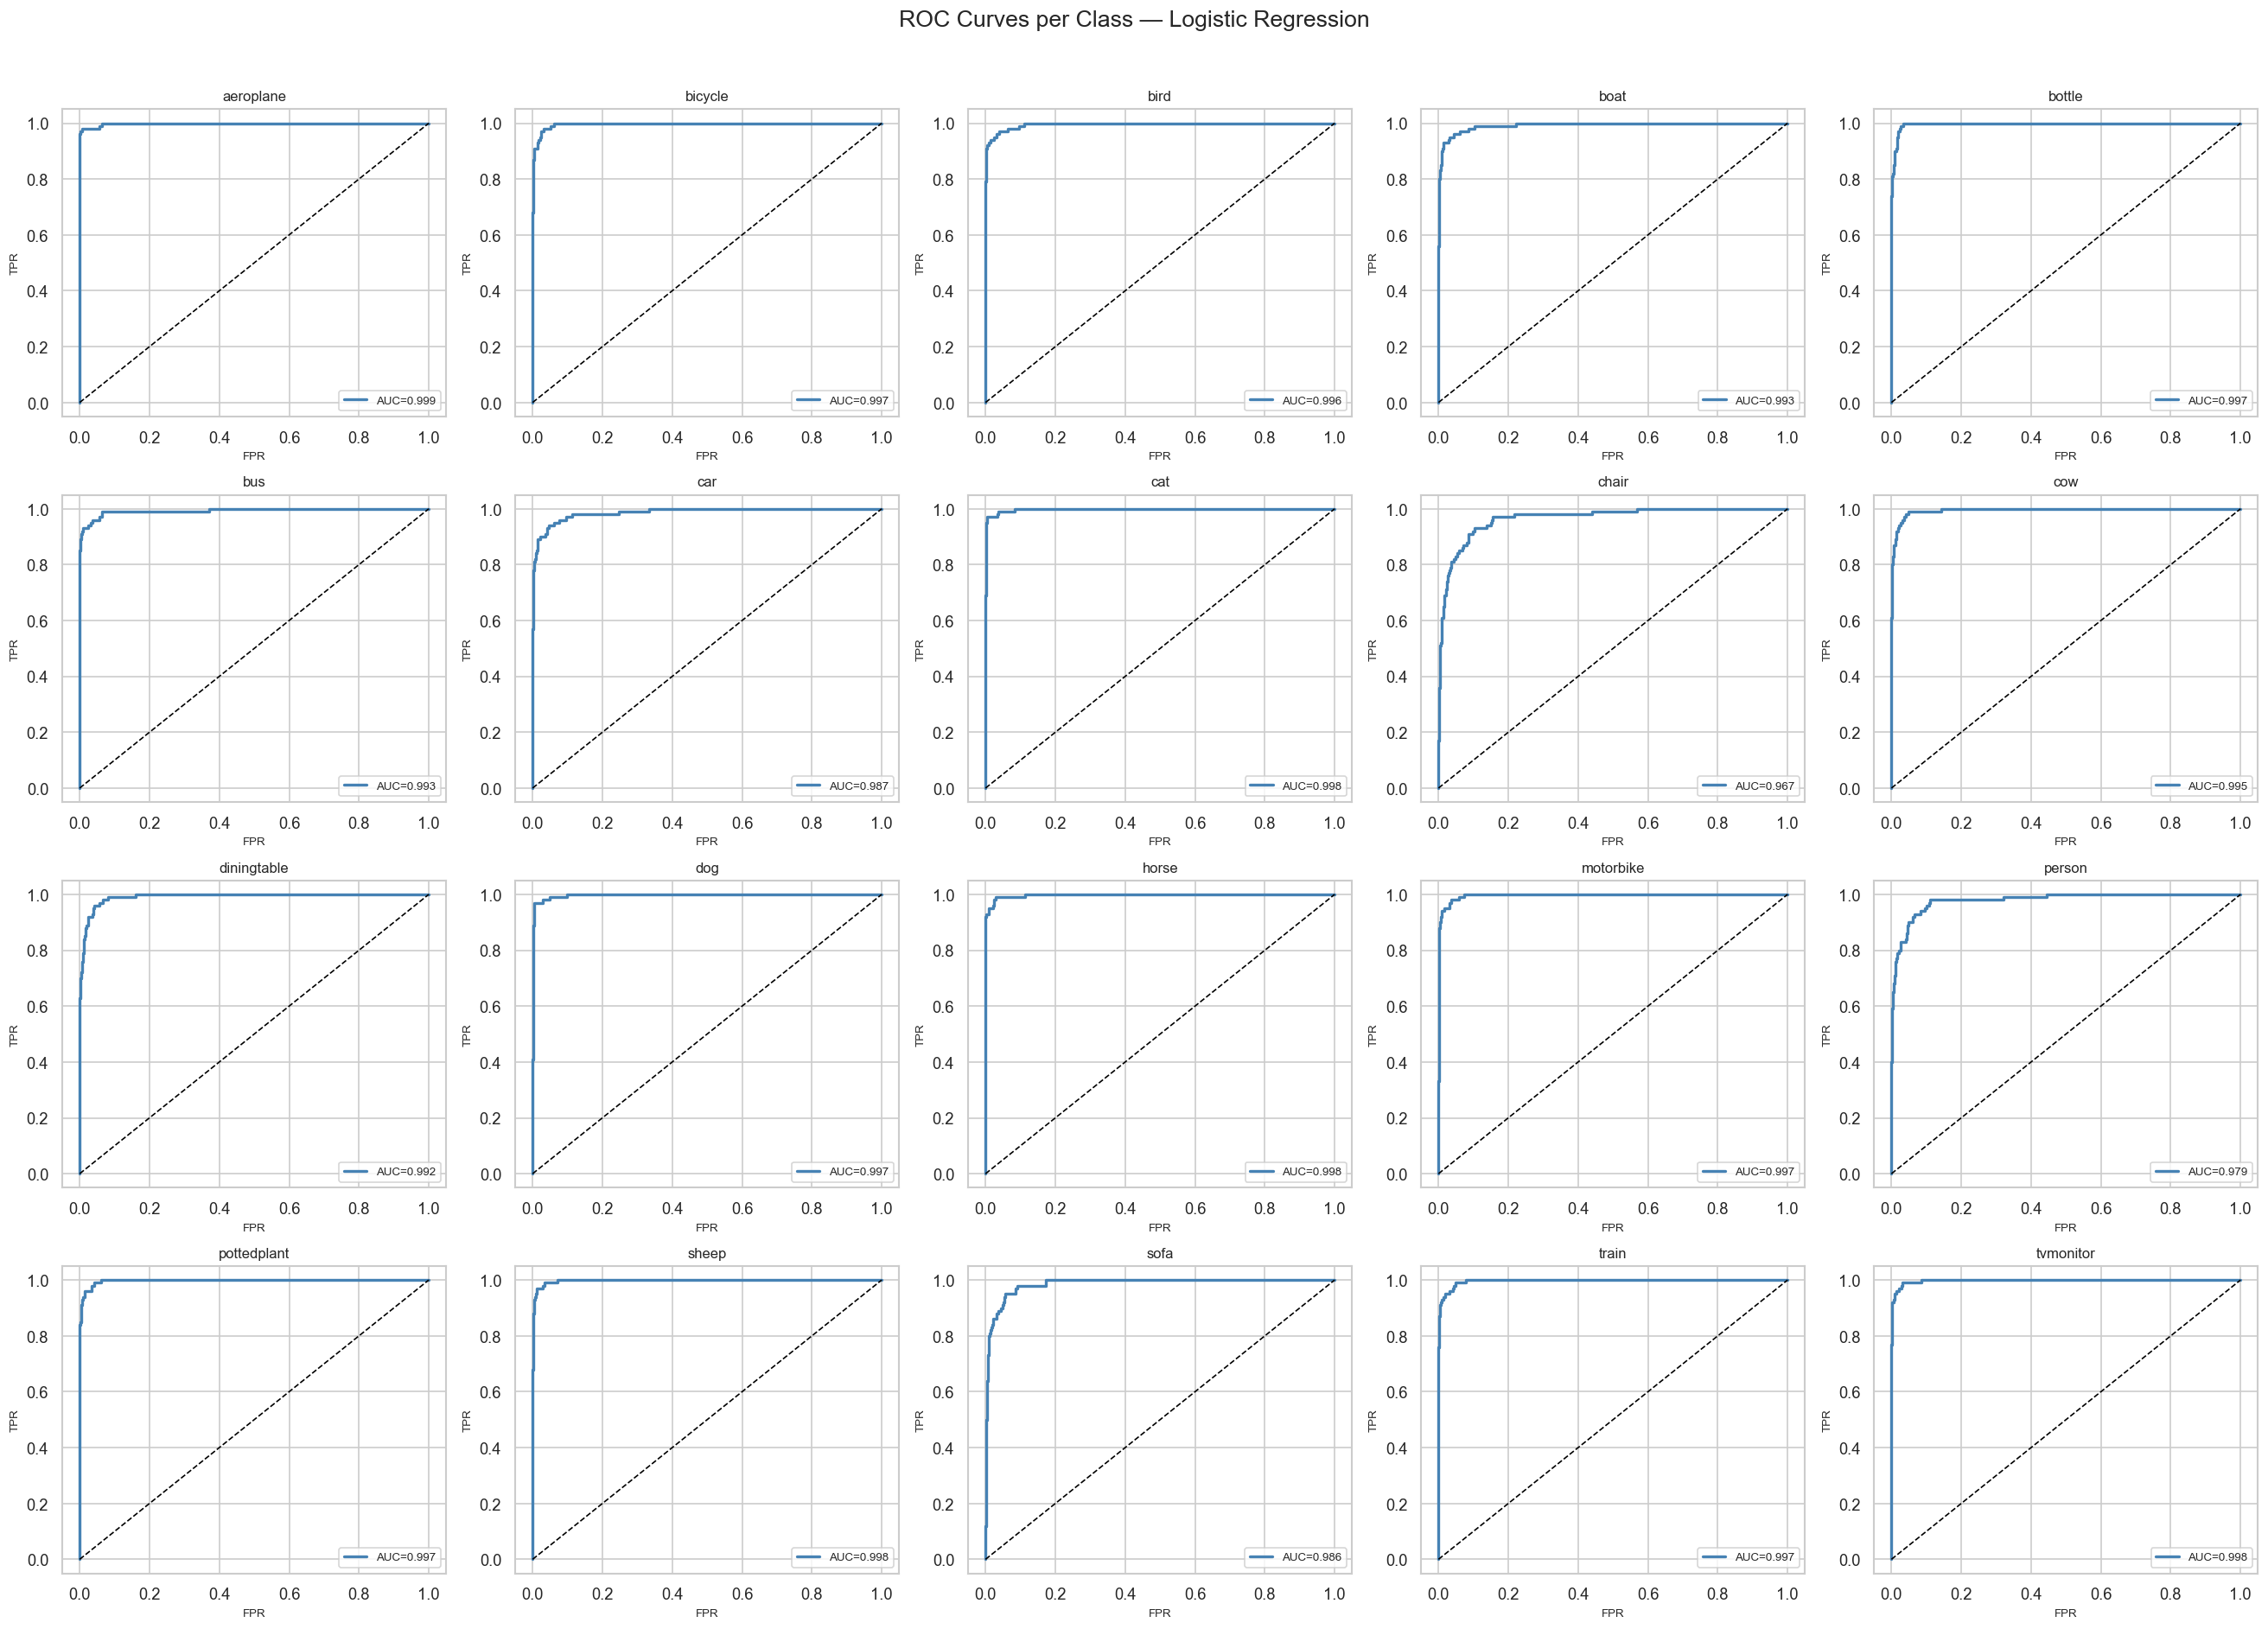

In [44]:
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

def get_metrics(y_true, y_pred, name):
    return {
        'Model'        : name,
        'Accuracy'     : round(accuracy_score(y_true, y_pred), 4),
        'F1 Weighted'  : round(f1_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'F1 Macro'     : round(f1_score(y_true, y_pred, average='macro',    zero_division=0), 4),
        'Precision (W)': round(precision_score(y_true, y_pred, average='weighted', zero_division=0), 4),
        'Recall (W)'   : round(recall_score(y_true, y_pred, average='weighted',    zero_division=0), 4),
    }

results = []
for name in models_to_train.keys():
    results.append(get_metrics(y_test, y_preds[name], name))

results_df = pd.DataFrame(results).set_index('Model')

print('=' * 65)
print('              FINAL MODEL PERFORMANCE ANALYSIS')
print('=' * 65)
display(results_df)

best_model_name = results_df['F1 Weighted'].idxmax()
print(f'\n Best Model: {best_model_name}  (F1={results_df.loc[best_model_name,"F1 Weighted"]})')

print(f'\n=========================================================')
print(f'  Per-Class Report — {best_model_name}:')
print('=========================================================')
print(classification_report(y_test, y_preds[best_model_name],
                            target_names=le_cnn.classes_, zero_division=0))

# Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_preds[best_model_name]),
    display_labels=le_cnn.classes_
).plot(ax=axes[0], cmap='Blues', colorbar=True, xticks_rotation=45)
axes[0].set_title(f'Confusion Matrix (counts) — {best_model_name}', fontsize=13)

cm_norm = confusion_matrix(y_test, y_preds[best_model_name]).astype(float)
cm_norm /= cm_norm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(
    cm_norm.round(2), display_labels=le_cnn.classes_
).plot(ax=axes[1], cmap='Greens', colorbar=True, xticks_rotation=45)
axes[1].set_title(f'Confusion Matrix (normalised) — {best_model_name}', fontsize=13)

plt.tight_layout()
plt.show()

# ROC AUC Analysis
n_classes  = len(le_cnn.classes_)
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

if best_model_name in y_probs:
    best_prob = y_probs[best_model_name]
    macro_auc = roc_auc_score(y_test_bin, best_prob, multi_class='ovr', average='macro')
    print(f'\nMacro AUC (OvR) — {best_model_name}: {macro_auc:.4f}')

    fig, axes = plt.subplots(4, 5, figsize=(22, 16))
    axes = axes.flatten()
    for i, cls in enumerate(le_cnn.classes_):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_prob[:, i])
        axes[i].plot(fpr, tpr, color='steelblue', lw=2, label=f'AUC={auc(fpr,tpr):.3f}')
        axes[i].plot([0,1],[0,1],'k--', lw=1)
        axes[i].set_title(cls, fontsize=10)
        axes[i].set_xlabel('FPR', fontsize=8)
        axes[i].set_ylabel('TPR', fontsize=8)
        axes[i].legend(fontsize=8)

    plt.suptitle(f'ROC Curves per Class — {best_model_name}', fontsize=16)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()


In [46]:
import joblib
import os
from sklearn.linear_model import LogisticRegression

SAVE_DIR = 'saved_model'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Explicitly define and train your best model so the 'clf' variable exists
clf = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
# Note: Since you are saving the scaler separately, you should fit the clf on the scaled training data
X_train_scaled = scaler.transform(X_train)
clf.fit(X_train_scaled, y_train)

# 2. Save classifier, scaler and label encoder 
# (Changed le_cnn to le to match your actual label encoder variable)
joblib.dump(clf,     os.path.join(SAVE_DIR, 'classifier.pkl'))
joblib.dump(scaler,  os.path.join(SAVE_DIR, 'scaler.pkl'))
joblib.dump(le,      os.path.join(SAVE_DIR, 'label_encoder.pkl'))

print(f'Model saved to {SAVE_DIR}/ ✅')
print(f'  classifier.pkl')
print(f'  scaler.pkl')
print(f'  label_encoder.pkl')

Model saved to saved_model/ ✅
  classifier.pkl
  scaler.pkl
  label_encoder.pkl
